In [1]:
!pip install matplotlib opencv-python-headless


In [2]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 32

IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512

DATA_PATH = "processed_data"


In [9]:
import os

!pip install gdown

if not os.path.exists("processed_data.zip"):
    print("Downloading dataset from Google Drive...")
    !gdown 1jJps8JoGo-cBjmUeJNH0gpndaQ4K2Otr
else:
    print("Zip file already exists.")

import zipfile
if os.path.exists("processed_data.zip"):
    print("Extracting dataset...")
    with zipfile.ZipFile("processed_data.zip", 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Dataset is ready. processed_data directory is available.")
else:
    print("Download failed. Please check the file ID.")


  Using cached gdown-5.2.0-py3-none-any.whl.metadata (5.8 kB)
Using cached gdown-5.2.0-py3-none-any.whl (18 kB)
Zip file already exists.
Extracting dataset...
Dataset is ready. processed_data directory is available.


In [ ]:
# Patient-aware split
all_image_paths = sorted(glob.glob(os.path.join(DATA_PATH, "images", "*.npy")))
all_mask_paths = sorted(glob.glob(os.path.join(DATA_PATH, "masks", "*.npy")))

print(f"Total images found: {len(all_image_paths)}")

patient_map = {}
for img_path, mask_path in zip(all_image_paths, all_mask_paths):
    filename = os.path.basename(img_path)
    p_id = filename.rsplit('_', 1)[0]

    if p_id not in patient_map:
        patient_map[p_id] = {'images': [], 'masks': []}

    patient_map[p_id]['images'].append(img_path)
    patient_map[p_id]['masks'].append(mask_path)

patient_ids = list(patient_map.keys())
print(f"Unique patients: {len(patient_ids)}")

test_pids = patient_ids[-2:]
val_pids = patient_ids[-4:-2]
train_pids = patient_ids[:-4]

print(f"Train: {len(train_pids)} | Val: {len(val_pids)} | Test: {len(test_pids)}")

def get_paths(p_ids_list):
    imgs, msks = [], []
    for pid in p_ids_list:
        imgs.extend(patient_map[pid]['images'])
        msks.extend(patient_map[pid]['masks'])
    return imgs, msks

train_imgs, train_masks = get_paths(train_pids)
val_imgs, val_masks = get_paths(val_pids)
test_imgs, test_masks = get_paths(test_pids)


Total images found: 2074
Unique patients: 20
Train: 16 | Val: 2 | Test: 2


In [15]:
class LiverDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.load(self.image_paths[idx]).astype(np.float32)
        mask = np.load(self.mask_paths[idx]).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        else:
            image = cv2.resize(image, (IMAGE_WIDTH, IMAGE_HEIGHT))
            mask = cv2.resize(mask, (IMAGE_WIDTH, IMAGE_HEIGHT), interpolation=cv2.INTER_NEAREST)
            image = torch.from_numpy(image).unsqueeze(0)
            mask = torch.from_numpy(mask).long()

        return image, mask.long()


train_transform = A.Compose([
    A.Rotate(limit=15, p=0.5),
    A.HorizontalFlip(p=0.0),
    A.VerticalFlip(p=0.5),
    A.RandomScale(scale_limit=0.1, p=0.5),
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
    ToTensorV2()
])


train_loader = DataLoader(
    LiverDataset(train_imgs, train_masks, transform=train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True
)

val_loader = DataLoader(
    LiverDataset(val_imgs, val_masks, transform=val_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True
)

test_loader = DataLoader(
    LiverDataset(test_imgs, test_masks, transform=val_transform),
    batch_size=1,
    shuffle=False,
    num_workers=0
)


In [ ]:
class DenseUNet169(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        
        self.base_model = models.densenet169(weights=models.DenseNet169_Weights.DEFAULT)
        self.base_model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # We will have 64 feature maps
        #Each filter is 7x7
        #This is the same selection as the original ResNet and DenseNet.
        # output (batch=1, channels=64, height=256, width=256)

        #First block in the encoder
        self.enc0 = nn.Sequential(self.base_model.features.conv0, self.base_model.features.norm0, self.base_model.features.relu0)
        self.pool0 = self.base_model.features.pool0
        self.denseblock1 = self.base_model.features.denseblock1
        self.transition1 = self.base_model.features.transition1
        self.denseblock2 = self.base_model.features.denseblock2
        self.transition2 = self.base_model.features.transition2
        self.denseblock3 = self.base_model.features.denseblock3
        self.transition3 = self.base_model.features.transition3
        self.denseblock4 = self.base_model.features.denseblock4

        self.up1 = nn.ConvTranspose2d(1664, 832, kernel_size=2, stride=2)
        self.conv1 = nn.Sequential(
            nn.Conv2d(832 + 1280, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(inplace=True)
        )

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = nn.Sequential(
            nn.Conv2d(256 + 512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True)
        )

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = nn.Sequential(
            nn.Conv2d(128 + 256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True)
        )

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True)
        )

        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoding
        # x.shape = (1, 1, 512, 512)
        x0 = self.enc0(x); 
        # x0.shape = (1, 64, 256, 256)
        x1 = self.pool0(x0)
        # x1.shape = (1, 64, 128, 128)
        x1 = self.denseblock1(x1) # Skip 3
        # x1.shape = (1, 256, 128, 128)
        x2 = self.transition1(x1); x2 = self.denseblock2(x2) # Skip 2   x2.shape = (1, 512, 64, 64)
        x3 = self.transition2(x2); x3 = self.denseblock3(x3) # Skip 1   x3.shape = (1, 1280, 32, 32)
        x4 = self.transition3(x3); x4 = self.denseblock4(x4) # Bottleneck    x4.shape = (1, 1664, 16, 16)
        #  Deepest representation

        # Decoding
        # (1, 1664, 16, 16)
        d1 = self.up1(x4)
        # d1.shape = (1, 832, 32, 32)

        # Check the size so concat
        if d1.shape != x3.shape: d1 = torch.nn.functional.interpolate(d1, size=x3.shape[2:])
        # concat --> ( d1-->(1, 832, 32, 32) + x3-->(1, 1280, 32, 32) )
        d1 = torch.cat((d1, x3), dim=1)
        # (1, 2112, 32, 32)
        d1 = self.conv1(d1)
        # (1, 512, 32, 32)
        d2 = self.up2(d1)
        # d2.shape = (1, 256, 64, 64)
        if d2.shape != x2.shape: d2 = torch.nn.functional.interpolate(d2, size=x2.shape[2:])
        d2 = torch.cat((d2, x2), dim=1)
        # (1, 768, 64, 64)
        d2 = self.conv2(d2)
        # d2.shape = (1, 256, 64, 64)
        d3 = self.up3(d2)
        # (1,128,128,128)
        if d3.shape != x1.shape: d3 = torch.nn.functional.interpolate(d3, size=x1.shape[2:])
        d3 = torch.cat((d3, x1), dim=1)
        # concat --> (1, 384, 128, 128)
        d3 = self.conv3(d3)
        # (1, 128, 128, 128)
        d4 = self.up4(d3)
        # (1, 64, 256, 256)
        if d4.shape != x0.shape: d4 = torch.nn.functional.interpolate(d4, size=x0.shape[2:])
        d4 = torch.cat((d4, x0), dim=1)
        # concat --> (1, 128, 256, 256)
        d4 = self.conv4(d4)
        # (1, 64, 256, 256)

        out = self.final_up(d4)
        # (1, 32, 512, 512)
        return self.final_conv(out)

In [ ]:
# 1. Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = torch.softmax(inputs, dim=1)
        
        # Tumor Dice
        input_tumor = inputs[:, 2].contiguous().view(-1)
        target_tumor = (targets == 2).float().contiguous().view(-1)
        dice_tumor = (2. * (input_tumor * target_tumor).sum() + self.smooth) / (input_tumor.sum() + target_tumor.sum() + self.smooth)
        
        # Liver Dice
        input_liver = inputs[:, 1].contiguous().view(-1)
        target_liver = (targets == 1).float().contiguous().view(-1)
        dice_liver = (2. * (input_liver * target_liver).sum() + self.smooth) / (input_liver.sum() + target_liver.sum() + self.smooth)
        
        return 1 - (0.4 * dice_liver + 0.6 * dice_tumor)





In [ ]:
#التجربة 1
EPOCHS = 100

model = DenseUNet169(n_classes=3).to(DEVICE)

weights = torch.tensor([0.1, 1.0, 5.0]).to(DEVICE)
criterion_ce = nn.CrossEntropyLoss(weight=weights)
criterion_dice = DiceLoss(smooth=1)

optimizer = optim.AdamW(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)
scaler = torch.cuda.amp.GradScaler()

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

print(f"Starting training for {EPOCHS} epochs")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for images, masks in loop:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss_ce = criterion_ce(outputs, masks)
            loss_dice = criterion_dice(outputs, masks)
            loss = 0.3 * loss_ce + 0.7 * loss_dice

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            outputs = model(images)
            l_ce = criterion_ce(outputs, masks)
            l_dice = criterion_dice(outputs, masks)
            val_loss += (0.3 * l_ce + 0.7 * l_dice).item()

    avg_train = running_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    scheduler.step(avg_val)

    print(
        f"Train Loss: {avg_train:.4f} | "
        f"Val Loss: {avg_val:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "best_model_169.pth")
        print("Best model saved")

print("Training completed")

plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.title("Training Loss Curve")
plt.legend()
plt.show()


In [ ]:
'''
/tmp/ipykernel_1777/2818833425.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
 Start LONG Training (100 Epochs) with Scheduler...
Epoch 1/100:   0%|          | 0/53 [00:00<?, ?it/s]/tmp/ipykernel_1777/2818833425.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.788]
 Train: 0.8487 | Val: 0.9071 | LR: 0.000100
 Best Model Saved!
Epoch 2/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.671]
 Train: 0.7231 | Val: 0.7610 | LR: 0.000100
 Best Model Saved!
Epoch 3/100: 100%|██████████| 53/53 [00:26<00:00,  1.96it/s, loss=0.58] 
 Train: 0.6388 | Val: 0.6647 | LR: 0.000100
 Best Model Saved!
Epoch 4/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.559]
 Train: 0.5634 | Val: 0.6400 | LR: 0.000100
 Best Model Saved!
Epoch 5/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.473]
 Train: 0.4975 | Val: 0.5881 | LR: 0.000100
 Best Model Saved!
Epoch 6/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.346]
 Train: 0.4333 | Val: 0.5396 | LR: 0.000100
 Best Model Saved!
Epoch 7/100: 100%|██████████| 53/53 [00:28<00:00,  1.89it/s, loss=0.255]
 Train: 0.3386 | Val: 0.5405 | LR: 0.000100
Epoch 8/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.362]
 Train: 0.2252 | Val: 0.6095 | LR: 0.000100
Epoch 9/100: 100%|██████████| 53/53 [00:27<00:00,  1.96it/s, loss=0.151]
 Train: 0.1535 | Val: 0.5654 | LR: 0.000100
Epoch 10/100: 100%|██████████| 53/53 [00:28<00:00,  1.89it/s, loss=0.067] 
 Train: 0.1187 | Val: 0.5391 | LR: 0.000100
 Best Model Saved!
Epoch 11/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.095] 
 Train: 0.0846 | Val: 0.5054 | LR: 0.000100
Epoch 12/100: 100%|██████████| 53/53 [00:27<00:00,  1.96it/s, loss=0.435] 
 Train: 0.0829 | Val: 0.4919 | LR: 0.000100
 Best Model Saved!
Epoch 13/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.0425]
 Train: 0.0675 | Val: 0.4955 | LR: 0.000100
Epoch 14/100: 100%|██████████| 53/53 [00:26<00:00,  1.97it/s, loss=0.0629]
 Train: 0.0680 | Val: 0.5047 | LR: 0.000100
Epoch 15/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.0572]
 Train: 0.0644 | Val: 0.4668 | LR: 0.000100
 Best Model Saved!
Epoch 16/100: 100%|██████████| 53/53 [00:27<00:00,  1.89it/s, loss=0.13]  
 Train: 0.0622 | Val: 0.5102 | LR: 0.000100
Epoch 17/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0754]
 Train: 0.0831 | Val: 0.5928 | LR: 0.000100
Epoch 18/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.104] 
 Train: 0.0741 | Val: 0.7062 | LR: 0.000100
Epoch 19/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.0861]
 Train: 0.0654 | Val: 0.5907 | LR: 0.000100
Epoch 20/100: 100%|██████████| 53/53 [00:27<00:00,  1.95it/s, loss=0.0476]
 Train: 0.0567 | Val: 0.5877 | LR: 0.000100
Epoch 21/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.17]  
 Train: 0.0543 | Val: 0.5548 | LR: 0.000050
Epoch 22/100: 100%|██████████| 53/53 [00:28<00:00,  1.89it/s, loss=0.0391]
 Train: 0.0526 | Val: 0.5935 | LR: 0.000050
Epoch 23/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0472]
 Train: 0.0485 | Val: 0.5738 | LR: 0.000050
Epoch 24/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0929]
 Train: 0.0515 | Val: 0.5556 | LR: 0.000050
Epoch 25/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0864]
 Train: 0.0472 | Val: 0.5631 | LR: 0.000050
Epoch 26/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0737]
 Train: 0.0470 | Val: 0.5842 | LR: 0.000050
Epoch 27/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0589]
 Train: 0.0461 | Val: 0.5533 | LR: 0.000025
Epoch 28/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0522]
 Train: 0.0463 | Val: 0.5772 | LR: 0.000025
Epoch 29/100: 100%|██████████| 53/53 [00:27<00:00,  1.95it/s, loss=0.0249]
 Train: 0.0433 | Val: 0.5895 | LR: 0.000025
Epoch 30/100: 100%|██████████| 53/53 [00:27<00:00,  1.96it/s, loss=0.045] 
 Train: 0.0410 | Val: 0.6005 | LR: 0.000025
Epoch 31/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0743]
 Train: 0.0443 | Val: 0.5950 | LR: 0.000025
Epoch 32/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.418] 
 Train: 0.0514 | Val: 0.5606 | LR: 0.000025
Epoch 33/100: 100%|██████████| 53/53 [00:27<00:00,  1.95it/s, loss=0.0689]
 Train: 0.0431 | Val: 0.5557 | LR: 0.000013
Epoch 34/100: 100%|██████████| 53/53 [00:28<00:00,  1.89it/s, loss=0.0524]
 Train: 0.0427 | Val: 0.5710 | LR: 0.000013
Epoch 35/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0564]
 Train: 0.0429 | Val: 0.5608 | LR: 0.000013
Epoch 36/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.025] 
 Train: 0.0410 | Val: 0.5703 | LR: 0.000013
Epoch 37/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0439]
 Train: 0.0419 | Val: 0.5670 | LR: 0.000013
Epoch 38/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.0436]
 Train: 0.0413 | Val: 0.5932 | LR: 0.000013
Epoch 39/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.062] 
 Train: 0.0403 | Val: 0.5719 | LR: 0.000006
Epoch 40/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0362]
 Train: 0.0387 | Val: 0.5624 | LR: 0.000006
Epoch 41/100: 100%|██████████| 53/53 [00:27<00:00,  1.95it/s, loss=0.0402]
 Train: 0.0408 | Val: 0.5745 | LR: 0.000006
Epoch 42/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.0334]
 Train: 0.0397 | Val: 0.5803 | LR: 0.000006
Epoch 43/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.0259]
 Train: 0.0395 | Val: 0.5768 | LR: 0.000006
Epoch 44/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.117] 
 Train: 0.0406 | Val: 0.5773 | LR: 0.000006
Epoch 45/100: 100%|██████████| 53/53 [00:27<00:00,  1.95it/s, loss=0.0439]
 Train: 0.0390 | Val: 0.5764 | LR: 0.000003
Epoch 46/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0327]
 Train: 0.0397 | Val: 0.5804 | LR: 0.000003
Epoch 47/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0407]
 Train: 0.0402 | Val: 0.5750 | LR: 0.000003
Epoch 48/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0303]
 Train: 0.0398 | Val: 0.5779 | LR: 0.000003
Epoch 49/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0498]
 Train: 0.0389 | Val: 0.5730 | LR: 0.000003
Epoch 50/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0927]
 Train: 0.0386 | Val: 0.5775 | LR: 0.000003
Epoch 51/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0308]
 Train: 0.0374 | Val: 0.5796 | LR: 0.000002
Epoch 52/100: 100%|██████████| 53/53 [00:28<00:00,  1.88it/s, loss=0.0289]
 Train: 0.0379 | Val: 0.5732 | LR: 0.000002
Epoch 53/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0381]
 Train: 0.0386 | Val: 0.5808 | LR: 0.000002
Epoch 54/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0548]
 Train: 0.0380 | Val: 0.5795 | LR: 0.000002
Epoch 55/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.41]  
 Train: 0.0451 | Val: 0.5718 | LR: 0.000002
Epoch 56/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0391]
 Train: 0.0382 | Val: 0.5761 | LR: 0.000002
Epoch 57/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.0437]
 Train: 0.0384 | Val: 0.5862 | LR: 0.000001
Epoch 58/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.106] 
 Train: 0.0386 | Val: 0.5789 | LR: 0.000001
Epoch 59/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0484]
 Train: 0.0373 | Val: 0.5793 | LR: 0.000001
Epoch 60/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0351]
 Train: 0.0370 | Val: 0.5841 | LR: 0.000001
Epoch 61/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0267]
 Train: 0.0388 | Val: 0.5771 | LR: 0.000001
Epoch 62/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.033] 
 Train: 0.0372 | Val: 0.5863 | LR: 0.000001
Epoch 63/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0395]
 Train: 0.0382 | Val: 0.5827 | LR: 0.000000
Epoch 64/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0542]
 Train: 0.0371 | Val: 0.5810 | LR: 0.000000
Epoch 65/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0658]
 Train: 0.0368 | Val: 0.5725 | LR: 0.000000
Epoch 66/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.034] 
 Train: 0.0378 | Val: 0.5782 | LR: 0.000000
Epoch 67/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.189] 
 Train: 0.0393 | Val: 0.5749 | LR: 0.000000
Epoch 68/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0252]
 Train: 0.0373 | Val: 0.5750 | LR: 0.000000
Epoch 69/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0245]
 Train: 0.0371 | Val: 0.5766 | LR: 0.000000
Epoch 70/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0541]
 Train: 0.0371 | Val: 0.5739 | LR: 0.000000
Epoch 71/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.411] 
 Train: 0.0455 | Val: 0.5780 | LR: 0.000000
Epoch 72/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0229]
 Train: 0.0373 | Val: 0.5772 | LR: 0.000000
Epoch 73/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0338]
 Train: 0.0374 | Val: 0.5732 | LR: 0.000000
Epoch 74/100: 100%|██████████| 53/53 [00:28<00:00,  1.88it/s, loss=0.0231]
 Train: 0.0380 | Val: 0.5738 | LR: 0.000000
Epoch 75/100: 100%|██████████| 53/53 [00:27<00:00,  1.95it/s, loss=0.0523]
 Train: 0.0378 | Val: 0.5832 | LR: 0.000000
Epoch 76/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.069] 
 Train: 0.0378 | Val: 0.5785 | LR: 0.000000
Epoch 77/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0779]
 Train: 0.0383 | Val: 0.5827 | LR: 0.000000
Epoch 78/100: 100%|██████████| 53/53 [00:27<00:00,  1.95it/s, loss=0.0401]
 Train: 0.0389 | Val: 0.5802 | LR: 0.000000
Epoch 79/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0748]
 Train: 0.0380 | Val: 0.5804 | LR: 0.000000
Epoch 80/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0402]
 Train: 0.0375 | Val: 0.5806 | LR: 0.000000
Epoch 81/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0286]
 Train: 0.0381 | Val: 0.5801 | LR: 0.000000
Epoch 82/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0572]
 Train: 0.0382 | Val: 0.5771 | LR: 0.000000
Epoch 83/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0488]
 Train: 0.0374 | Val: 0.5798 | LR: 0.000000
Epoch 84/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0349]
 Train: 0.0374 | Val: 0.5814 | LR: 0.000000
Epoch 85/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0301]
 Train: 0.0381 | Val: 0.5791 | LR: 0.000000
Epoch 86/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0208]
 Train: 0.0363 | Val: 0.5727 | LR: 0.000000
Epoch 87/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0287]
 Train: 0.0375 | Val: 0.5825 | LR: 0.000000
Epoch 88/100: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.0462]
 Train: 0.0371 | Val: 0.5785 | LR: 0.000000
Epoch 89/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0429]
 Train: 0.0381 | Val: 0.5829 | LR: 0.000000
Epoch 90/100: 100%|██████████| 53/53 [00:28<00:00,  1.89it/s, loss=0.0282]
 Train: 0.0372 | Val: 0.5773 | LR: 0.000000
Epoch 91/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0343]
 Train: 0.0366 | Val: 0.5775 | LR: 0.000000
Epoch 92/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0522]
 Train: 0.0371 | Val: 0.5801 | LR: 0.000000
Epoch 93/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.058] 
 Train: 0.0389 | Val: 0.5706 | LR: 0.000000
Epoch 94/100: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.0407]
 Train: 0.0383 | Val: 0.5757 | LR: 0.000000
Epoch 95/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0491]
 Train: 0.0368 | Val: 0.5829 | LR: 0.000000
Epoch 96/100: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.0428]
 Train: 0.0386 | Val: 0.5814 | LR: 0.000000
Epoch 97/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0488]
 Train: 0.0391 | Val: 0.5813 | LR: 0.000000
Epoch 98/100: 100%|██████████| 53/53 [00:27<00:00,  1.95it/s, loss=0.0284]
 Train: 0.0376 | Val: 0.5835 | LR: 0.000000
Epoch 99/100: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.0704]
 Train: 0.0390 | Val: 0.5733 | LR: 0.000000
Epoch 100/100: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.0299]
 Train: 0.0379 | Val: 0.5805 | LR: 0.000000
 Training Completed!
'''

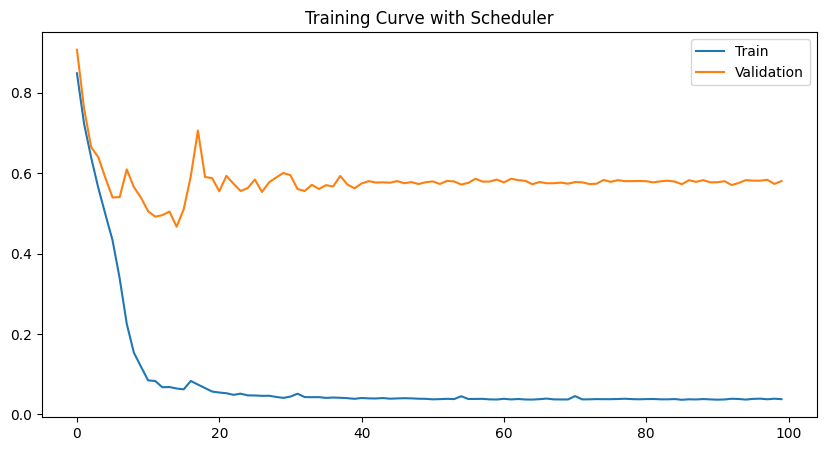

Model loaded successfully
Searching for tumor slices in test set
Found 59 slices with tumors out of 205


C:\Users\Motasem\AppData\Local\Temp\ipykernel_27164\333151077.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(image).unsqueeze(0).to(DEVICE)


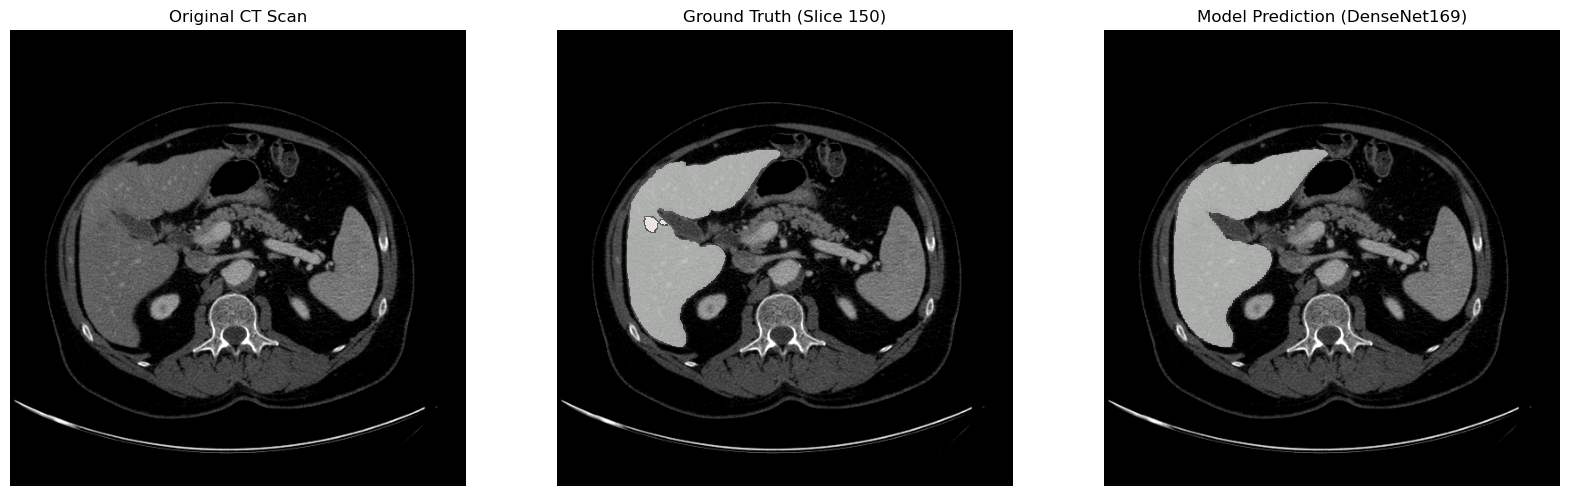

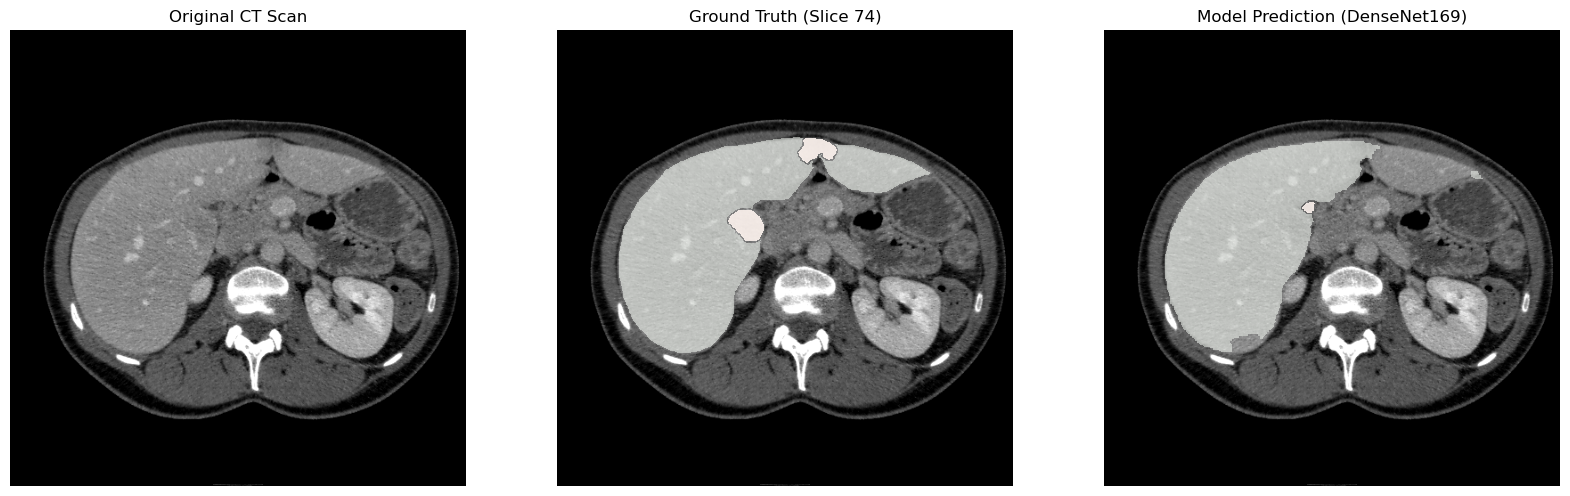

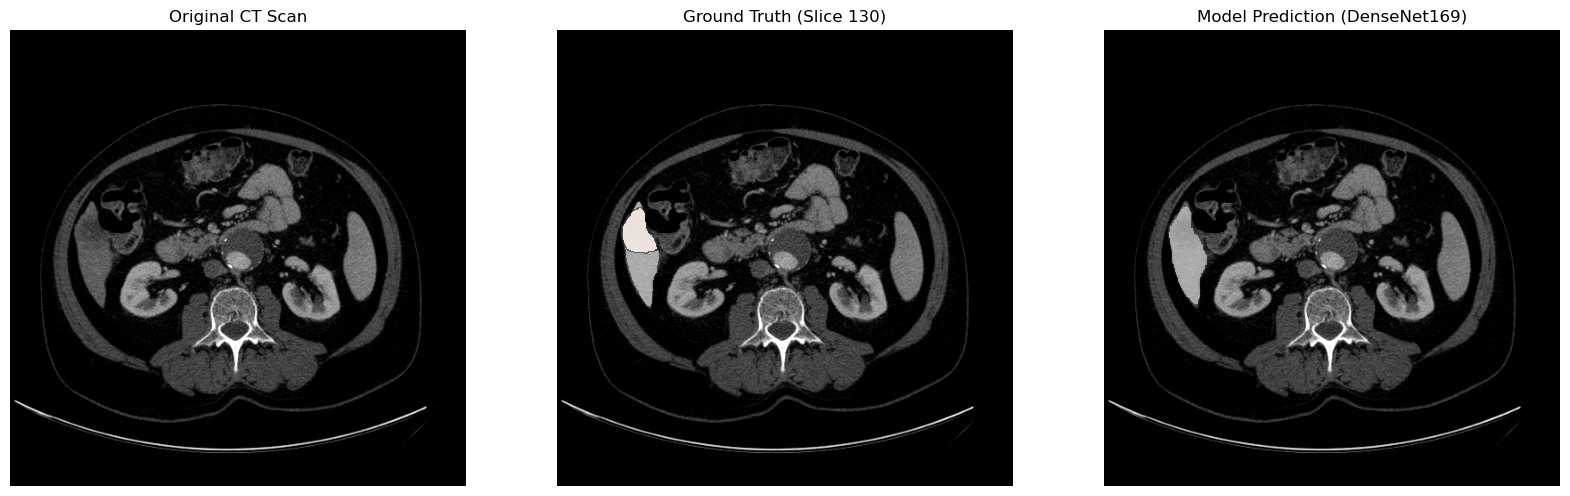

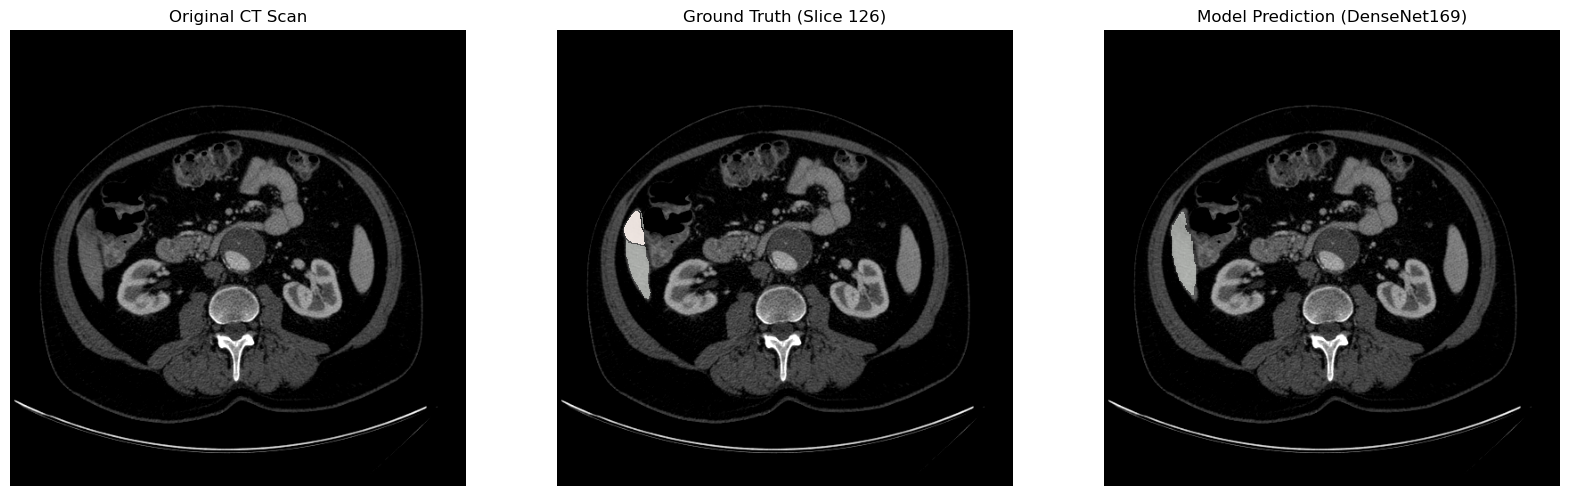

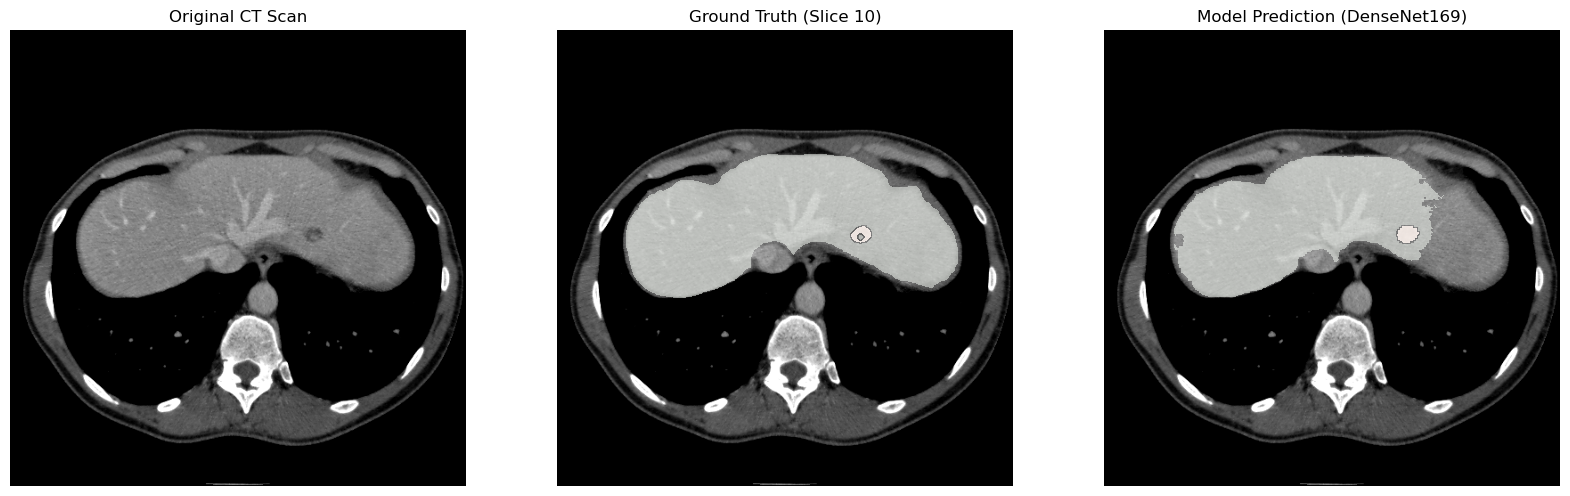

In [10]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

model = DenseUNet169(n_classes=3).to(DEVICE)

chk_path = "model_exp1_baseline.pth"

if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=DEVICE))

    print("Model loaded successfully")
else:
    print(f"Warning: '{chk_path}' not found")

model.eval()

def visualize_sample(dataset, idx):
    image, mask = dataset[idx]

    with torch.no_grad():
        input_tensor = torch.tensor(image).unsqueeze(0).to(DEVICE)
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).cpu().squeeze(0).numpy()

    image = image.squeeze(0).numpy()
    mask = mask.numpy()

    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title("Original CT Scan")
    ax[0].axis("off")

    ax[1].imshow(image, cmap="gray")
    ax[1].imshow(np.ma.masked_where(mask != 1, mask), cmap="Greens", alpha=0.5)
    ax[1].imshow(np.ma.masked_where(mask != 2, mask), cmap="Reds", alpha=0.9)
    ax[1].set_title(f"Ground Truth (Slice {idx})")
    ax[1].axis("off")

    ax[2].imshow(image, cmap="gray")
    ax[2].imshow(np.ma.masked_where(pred_mask != 1, pred_mask), cmap="Greens", alpha=0.5)
    ax[2].imshow(np.ma.masked_where(pred_mask != 2, pred_mask), cmap="Reds", alpha=0.9)
    ax[2].set_title("Model Prediction (DenseNet169)")
    ax[2].axis("off")

    plt.show()


print("Searching for tumor slices in test set")

tumor_indices = []

test_dataset_ref = test_loader.dataset

for i in range(len(test_dataset_ref)):
    _, m = test_dataset_ref[i]
    if 2 in m:
        tumor_indices.append(i)

print(f"Found {len(tumor_indices)} slices with tumors out of {len(test_dataset_ref)}")

if len(tumor_indices) > 0:
    num_show = min(5, len(tumor_indices))
    selected = random.sample(tumor_indices, num_show)

    for idx in selected:
        visualize_sample(test_dataset_ref, idx)
else:
    print("No tumor slices found in the test set")
    for i in range(3):
        visualize_sample(test_dataset_ref, i)


In [17]:
#نتائج تجربة 1
import numpy as np
import torch

def calculate_dice_metric(pred, target):
    smooth = 1e-5
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    intersection = (pred_flat * target_flat).sum()
    return (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)


print("Computing Dice scores")

model = DenseUNet169(n_classes=3).to(DEVICE)

chk_path = "model_exp1_baseline.pth"
if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=DEVICE))
    print("Model loaded successfully")
else:
    print("Warning: weights not found")

model.eval()

liver_scores = []
tumor_scores = []

with torch.no_grad():
    for image, mask in tqdm(test_loader):
        image = image.to(DEVICE)
        mask = mask.cpu().numpy()

        output = model(image)
        pred_mask = torch.argmax(output, dim=1).cpu().numpy()

        for j in range(image.shape[0]):
            curr_pred = pred_mask[j]
            curr_true = mask[j]

            if np.sum(curr_true == 1) > 0:
                p_liver = (curr_pred == 1).astype(float)
                t_liver = (curr_true == 1).astype(float)
                liver_scores.append(calculate_dice_metric(p_liver, t_liver))

            if np.sum(curr_true == 2) > 0:
                p_tumor = (curr_pred == 2).astype(float)
                t_tumor = (curr_true == 2).astype(float)
                tumor_scores.append(calculate_dice_metric(p_tumor, t_tumor))


print("=" * 40)
print("FINAL RESULTS (DenseNet169)")
print("=" * 40)
print(f"Liver Dice Score: {np.mean(liver_scores) * 100:.2f}%")

if len(tumor_scores) > 0:
    print(f"Tumor Dice Score: {np.mean(tumor_scores) * 100:.2f}%")
else:
    print("Tumor Dice Score: N/A")

print("=" * 40)


Computing Dice scores
Model loaded successfully


100%|██████████| 205/205 [01:44<00:00,  1.97it/s]

FINAL RESULTS (DenseNet169)
Liver Dice Score: 83.93%
Tumor Dice Score: 17.71%


In [ ]:
#التجربة الثانية 
class DiceLoss(nn.Module):
    def __init__(self, smooth=1):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = torch.softmax(inputs, dim=1)

        input_tumor = inputs[:, 2].contiguous().view(-1)
        target_tumor = (targets == 2).float().contiguous().view(-1)
        intersection_tumor = (input_tumor * target_tumor).sum()
        dice_tumor = (2.0 * intersection_tumor + self.smooth) / (
            input_tumor.sum() + target_tumor.sum() + self.smooth
        )

        input_liver = inputs[:, 1].contiguous().view(-1)
        target_liver = (targets == 1).float().contiguous().view(-1)
        intersection_liver = (input_liver * target_liver).sum()
        dice_liver = (2.0 * intersection_liver + self.smooth) / (
            input_liver.sum() + target_liver.sum() + self.smooth
        )

        return 1.0 - (0.4 * dice_liver + 0.6 * dice_tumor)


model = DenseUNet169(n_classes=3).to(DEVICE)

weights = torch.tensor([0.1, 1.0, 10.0]).to(DEVICE)

criterion_ce = nn.CrossEntropyLoss(weight=weights)
criterion_dice = DiceLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

print("Starting experiment 2")

for epoch in range(30):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/30")

    for images, masks in loop:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss_ce = criterion_ce(outputs, masks)
            loss_dice = criterion_dice(outputs, masks)
            loss = 0.5 * loss_ce + 0.5 * loss_dice

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            outputs = model(images)
            l_ce = criterion_ce(outputs, masks)
            l_dice = criterion_dice(outputs, masks)
            val_loss += (0.5 * l_ce + 0.5 * l_dice).item()

    avg_train = running_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "model_exp2_high_weights.pth")
        print("Best model saved")

print("Experiment 2 completed")


/tmp/ipykernel_1777/464986662.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


🔥 Start Experiment 2: High Weights (10.0) with Dice Protection...


Epoch 1/30:   0%|          | 0/53 [00:00<?, ?it/s]/tmp/ipykernel_1777/464986662.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100%|██████████| 53/53 [00:26<00:00,  1.96it/s, loss=0.736]


📉 Train: 0.8387 | Val: 0.8629
💾 Best Model Saved!


Epoch 2/30: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.659]


...

📉 Train: 0.0497 | Val: 0.6622


Epoch 29/30: 100%|██████████| 53/53 [00:27<00:00,  1.90it/s, loss=0.0664]


📉 Train: 0.0448 | Val: 0.7278


Epoch 30/30: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.302] 


📉 Train: 0.0497 | Val: 0.6852
🎉 Experiment 2 Completed!


Model loaded successfully
Searching for tumor slices in test set
Found 59 slices with tumors


C:\Users\Motasem\AppData\Local\Temp\ipykernel_27164\4165308649.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(image).unsqueeze(0).to(DEVICE)


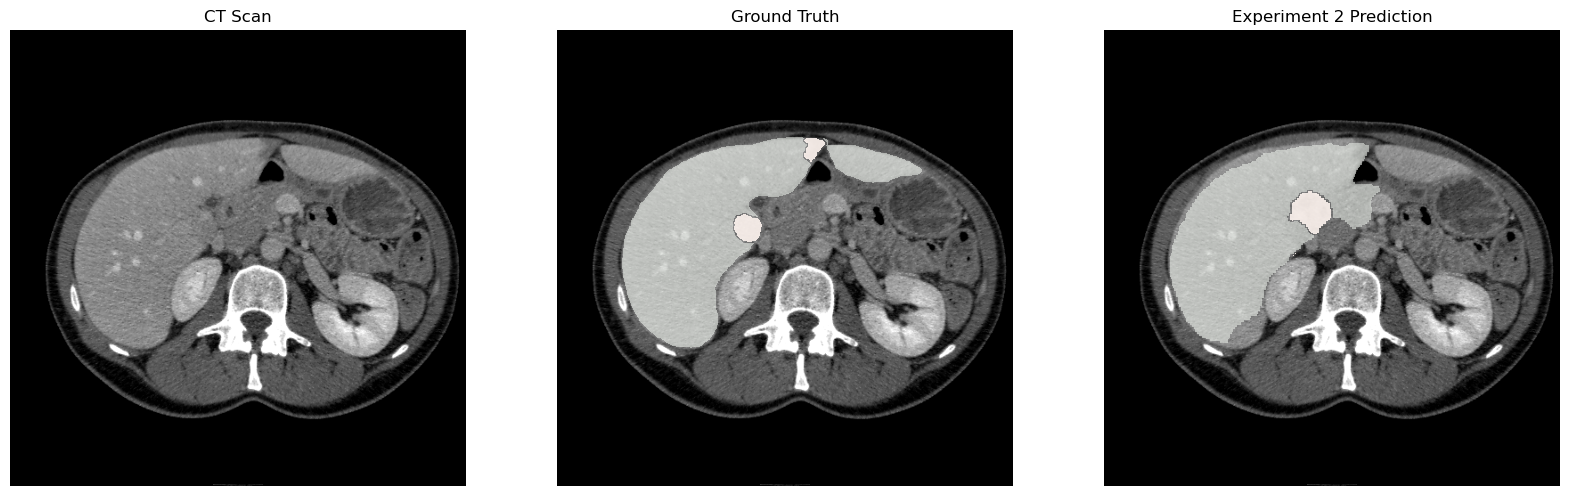

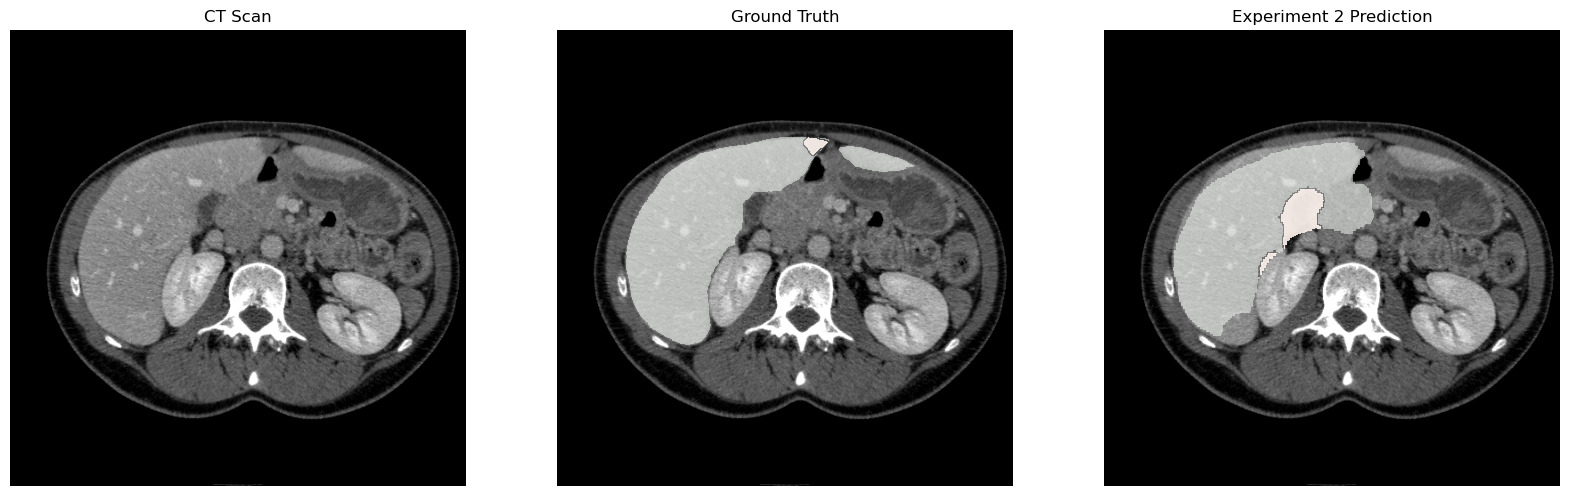

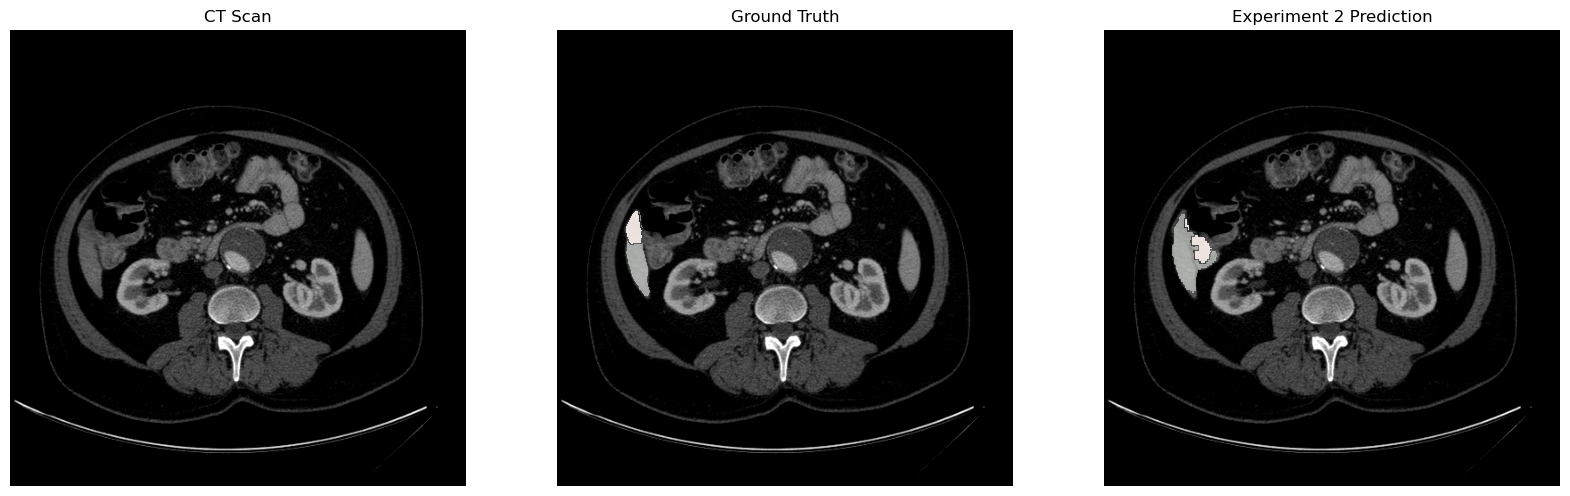

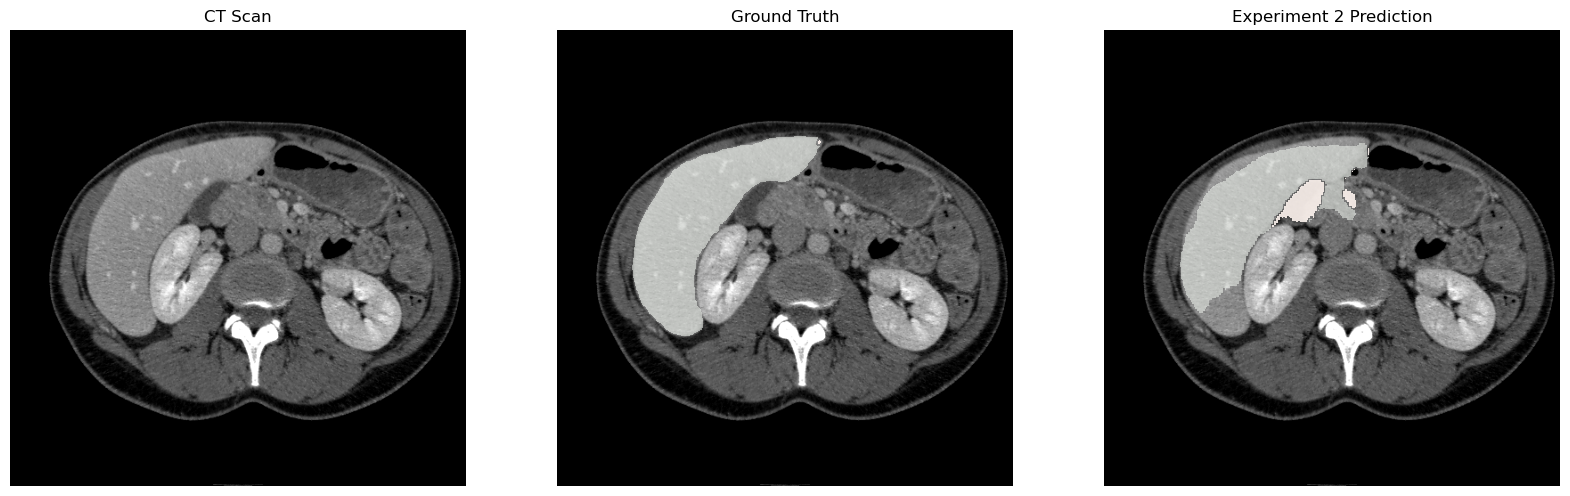

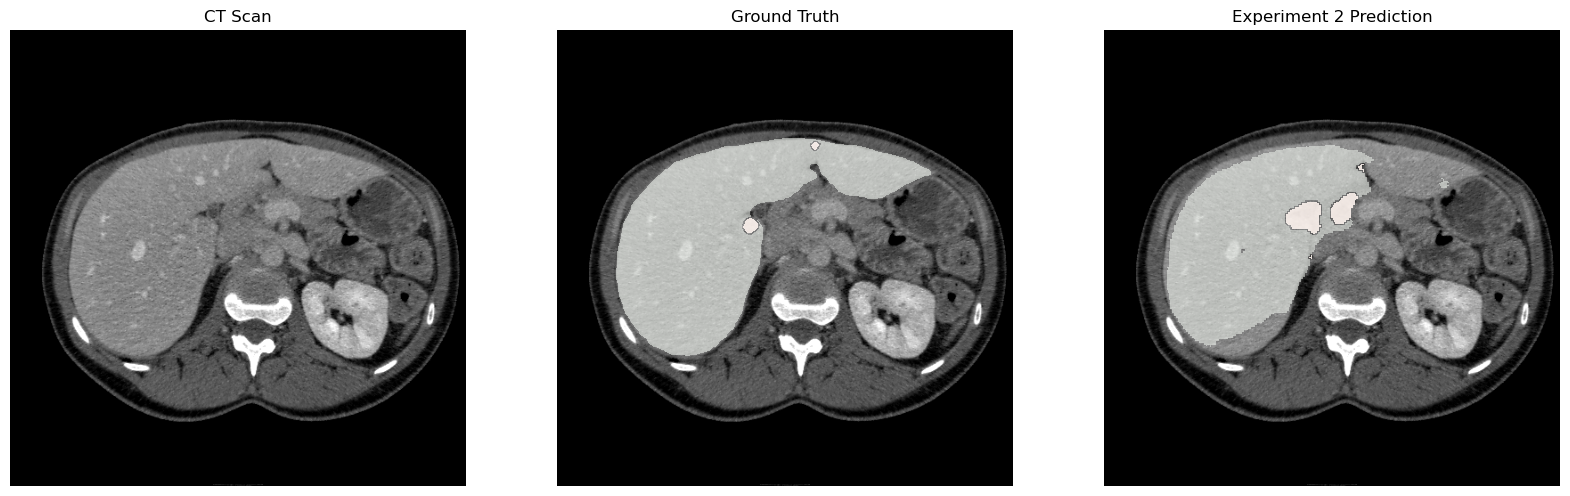

In [19]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

model = DenseUNet169(n_classes=3).to(DEVICE)

chk_path = "model_exp2_high_weights.pth"

if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=DEVICE))
    print("Model loaded successfully")
else:
    print(f"File '{chk_path}' not found")

model.eval()

def visualize_sample(dataset, idx):
    image, mask = dataset[idx]

    with torch.no_grad():
        input_tensor = torch.tensor(image).unsqueeze(0).to(DEVICE)
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).cpu().squeeze(0).numpy()

    image = image.squeeze(0).numpy()
    mask = mask.numpy()

    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title("CT Scan")
    ax[0].axis("off")

    ax[1].imshow(image, cmap="gray")
    ax[1].imshow(np.ma.masked_where(mask != 1, mask), cmap="Greens", alpha=0.5)
    ax[1].imshow(np.ma.masked_where(mask != 2, mask), cmap="Reds", alpha=0.9)
    ax[1].set_title("Ground Truth")
    ax[1].axis("off")

    ax[2].imshow(image, cmap="gray")
    ax[2].imshow(np.ma.masked_where(pred_mask != 1, pred_mask), cmap="Greens", alpha=0.5)
    ax[2].imshow(np.ma.masked_where(pred_mask != 2, pred_mask), cmap="Reds", alpha=0.9)
    ax[2].set_title("Experiment 2 Prediction")
    ax[2].axis("off")

    plt.show()


print("Searching for tumor slices in test set")

test_dataset_ref = test_loader.dataset
tumor_indices = []

for i in range(len(test_dataset_ref)):
    _, m = test_dataset_ref[i]
    if 2 in m:
        tumor_indices.append(i)

if len(tumor_indices) > 0:
    print(f"Found {len(tumor_indices)} slices with tumors")
    selected = random.sample(tumor_indices, min(5, len(tumor_indices)))
    for idx in selected:
        visualize_sample(test_dataset_ref, idx)
else:
    print("No tumor slices found")


In [20]:
#نتائج تجربة 2
import numpy as np
import torch

def calculate_dice_metric(pred, target):
    smooth = 1e-5
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    intersection = (pred_flat * target_flat).sum()
    return (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

print("Calculating metrics for Experiment 2 on test set")

model = DenseUNet169(n_classes=3).to(DEVICE)
chk_path = "model_exp2_high_weights.pth"

if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=DEVICE))
else:
    print("Weights not found")

model.eval()

liver_scores = []
tumor_scores = []

loader_to_test = test_loader

with torch.no_grad():
    for image, mask in loader_to_test:
        image = image.to(DEVICE)
        mask = mask.cpu().numpy()

        output = model(image)
        pred_mask = torch.argmax(output, dim=1).cpu().numpy()

        for j in range(image.shape[0]):
            curr_pred = pred_mask[j]
            curr_true = mask[j]

            if np.sum(curr_true == 1) > 0:
                p_liver = (curr_pred == 1).astype(float)
                t_liver = (curr_true == 1).astype(float)
                liver_scores.append(calculate_dice_metric(p_liver, t_liver))

            if np.sum(curr_true == 2) > 0:
                p_tumor = (curr_pred == 2).astype(float)
                t_tumor = (curr_true == 2).astype(float)
                tumor_scores.append(calculate_dice_metric(p_tumor, t_tumor))

print("=" * 40)
print("EXPERIMENT 2 RESULTS (TEST SET)")
print("=" * 40)
print(f"Liver Dice Score: {np.mean(liver_scores) * 100:.2f}%")

if len(tumor_scores) > 0:
    print(f"Tumor Dice Score: {np.mean(tumor_scores) * 100:.2f}%")
else:
    print("Tumor Dice Score: N/A")

print("=" * 40)


Calculating metrics for Experiment 2 on test set
EXPERIMENT 2 RESULTS (TEST SET)
Liver Dice Score: 77.37%
Tumor Dice Score: 20.31%


In [24]:
#التجربة الثالثة
model = DenseUNet169(n_classes=3).to(DEVICE)

weights = torch.tensor([0.1, 1.0, 10.0]).to(DEVICE)
criterion_ce = nn.CrossEntropyLoss(weight=weights)
criterion_dice = DiceLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-5)
scaler = torch.cuda.amp.GradScaler()

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

print("Starting experiment 3")

for epoch in range(30):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/30")

    for images, masks in loop:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss_ce = criterion_ce(outputs, masks)
            loss_dice = criterion_dice(outputs, masks)
            loss = 0.5 * loss_ce + 0.5 * loss_dice

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            outputs = model(images)
            l_ce = criterion_ce(outputs, masks)
            l_dice = criterion_dice(outputs, masks)
            val_loss += (0.5 * l_ce + 0.5 * l_dice).item()

    avg_train = running_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "model_exp3_low_lr.pth")
        print("Best model saved")

print("Experiment 3 completed")


/tmp/ipykernel_1777/3986251466.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


🔥 Start Experiment 3: Low Learning Rate (1e-5)...
الهدف: الحفاظ على دقة الورم مع تحسين دقة الكبد


Epoch 1/30:   0%|          | 0/53 [00:00<?, ?it/s]/tmp/ipykernel_1777/3986251466.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s, loss=0.905]


📉 Train: 0.9701 | Val: 0.9692
💾 Best Model Saved!


Epoch 2/30: 100%|██████████| 53/53 [00:27<00:00,  1.91it/s, loss=0.845]


...

📉 Train: 0.4701 | Val: 0.7142


Epoch 29/30: 100%|██████████| 53/53 [00:27<00:00,  1.93it/s, loss=0.491]


📉 Train: 0.4635 | Val: 0.7043


Epoch 30/30: 100%|██████████| 53/53 [00:27<00:00,  1.92it/s, loss=0.447]


📉 Train: 0.4558 | Val: 0.7059
🎉 Experiment 3 Completed!


Model loaded successfully
Searching for tumor slices in test set
Found 59 slices with tumors


C:\Users\Motasem\AppData\Local\Temp\ipykernel_27164\3207942643.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(image).unsqueeze(0).to(DEVICE)


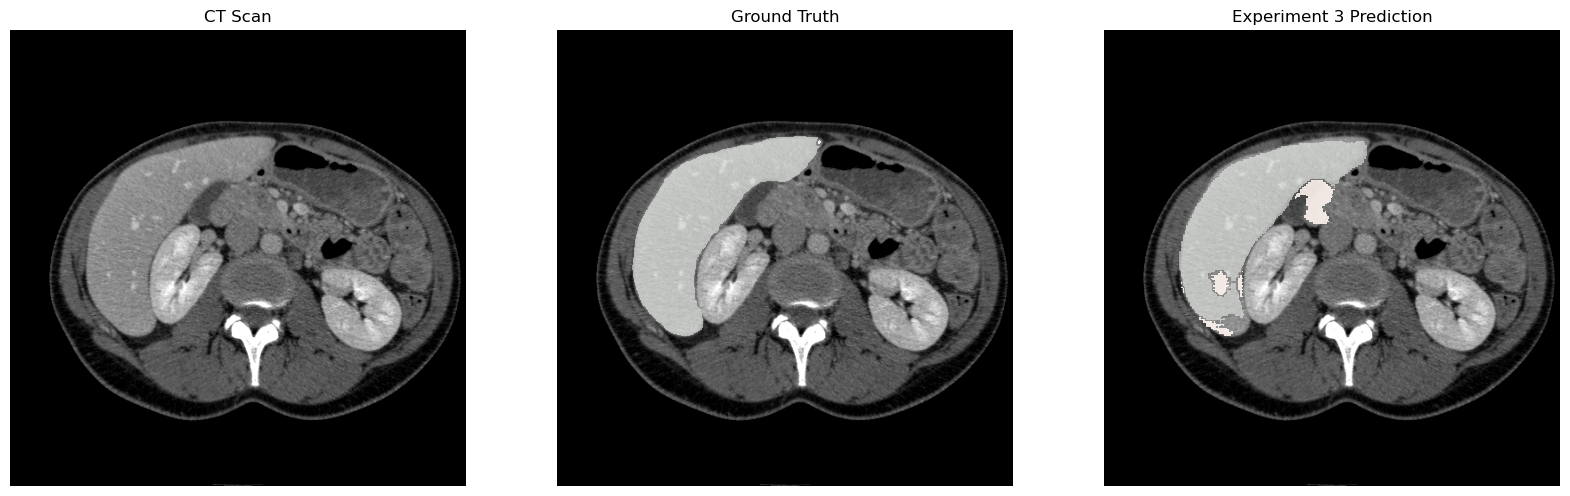

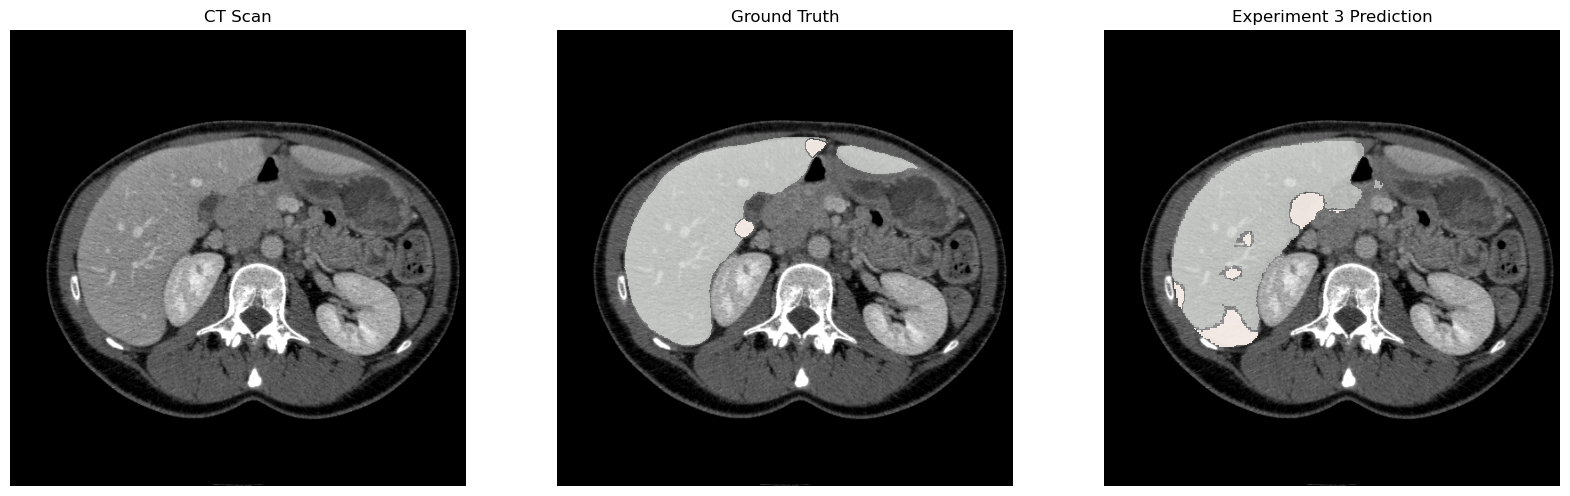

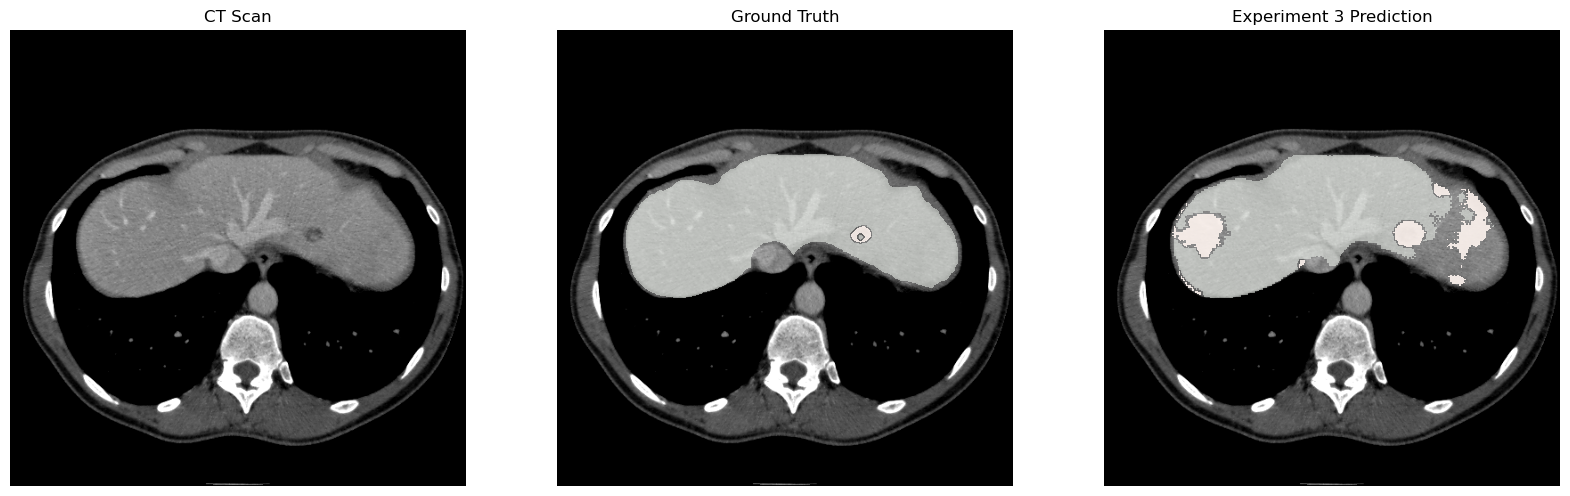

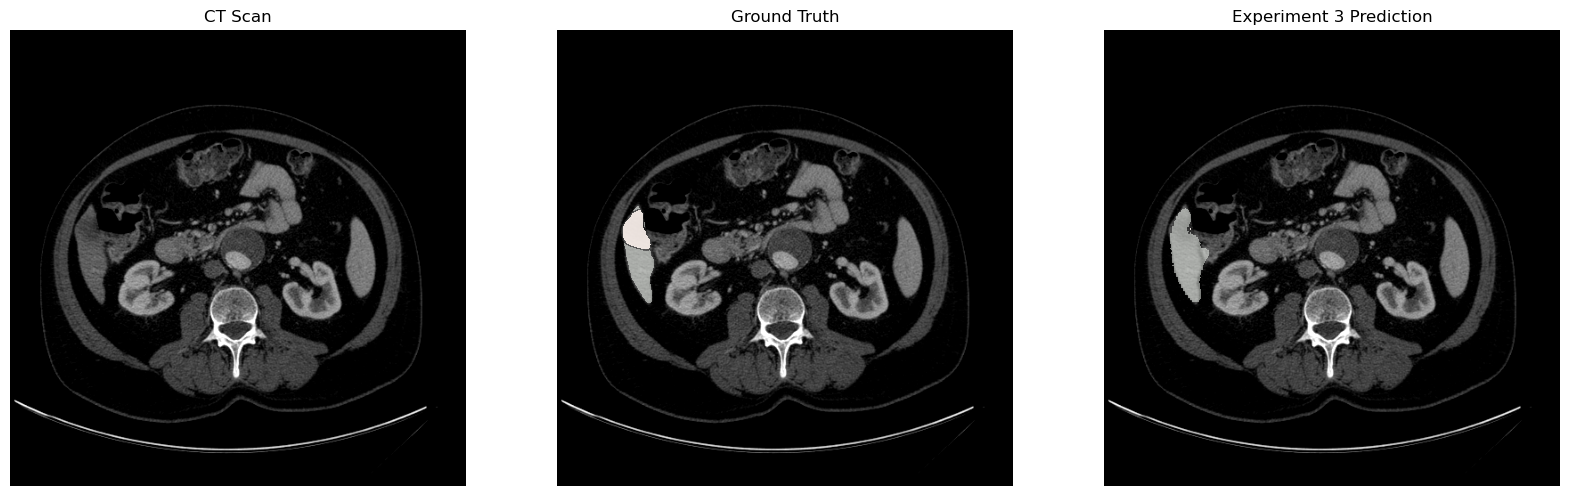

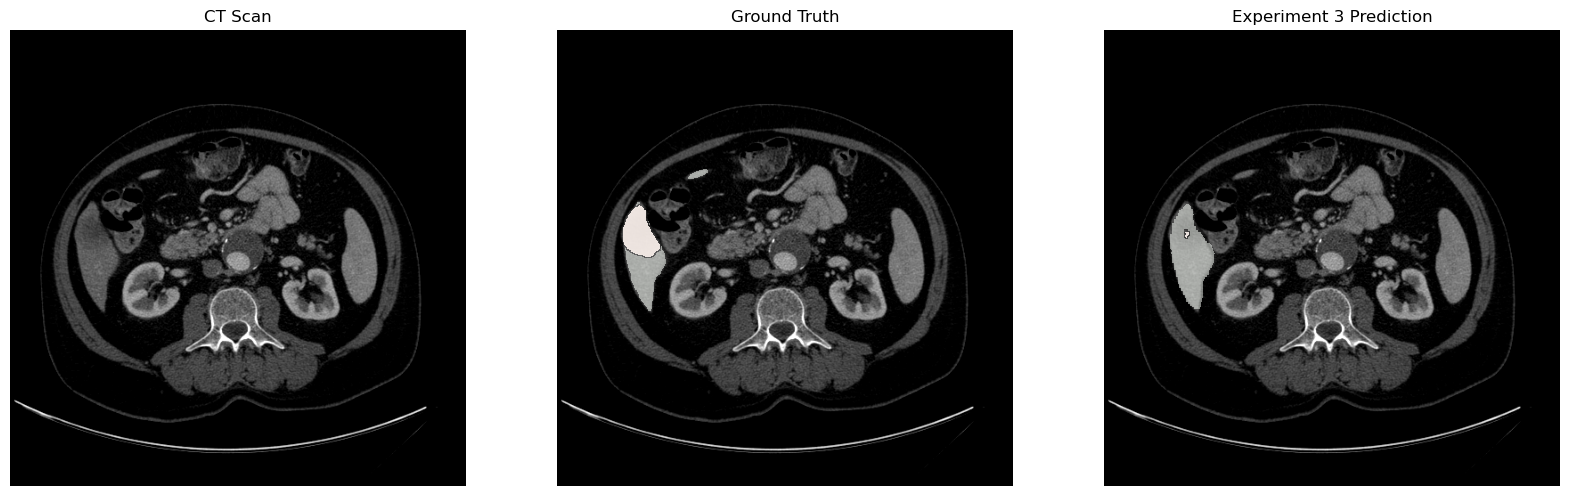

In [21]:
#نتائج التجربة الثالثة 
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

model = DenseUNet169(n_classes=3).to(DEVICE)

chk_path = "model_exp3_low_lr.pth"

if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=DEVICE))
    print("Model loaded successfully")
else:
    print(f"File '{chk_path}' not found")

model.eval()

def visualize_sample(dataset, idx):
    image, mask = dataset[idx]

    with torch.no_grad():
        input_tensor = torch.tensor(image).unsqueeze(0).to(DEVICE)
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).cpu().squeeze(0).numpy()

    image = image.squeeze(0).numpy()
    mask = mask.numpy()

    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title("CT Scan")
    ax[0].axis("off")

    ax[1].imshow(image, cmap="gray")
    ax[1].imshow(np.ma.masked_where(mask != 1, mask), cmap="Greens", alpha=0.5)
    ax[1].imshow(np.ma.masked_where(mask != 2, mask), cmap="Reds", alpha=0.9)
    ax[1].set_title("Ground Truth")
    ax[1].axis("off")

    ax[2].imshow(image, cmap="gray")
    ax[2].imshow(np.ma.masked_where(pred_mask != 1, pred_mask), cmap="Greens", alpha=0.5)
    ax[2].imshow(np.ma.masked_where(pred_mask != 2, pred_mask), cmap="Reds", alpha=0.9)
    ax[2].set_title("Experiment 3 Prediction")
    ax[2].axis("off")

    plt.show()


print("Searching for tumor slices in test set")

test_dataset_ref = test_loader.dataset
tumor_indices = []

for i in range(len(test_dataset_ref)):
    _, m = test_dataset_ref[i]
    if 2 in m:
        tumor_indices.append(i)

if len(tumor_indices) > 0:
    print(f"Found {len(tumor_indices)} slices with tumors")
    selected = random.sample(tumor_indices, min(5, len(tumor_indices)))
    for idx in selected:
        visualize_sample(test_dataset_ref, idx)
else:
    print("No tumor slices found")


In [22]:
#التجربة الثالثة نتائج 
import numpy as np
import torch
from tqdm import tqdm

def calculate_dice_metric(pred, target):
    smooth = 1e-5
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    intersection = (pred_flat * target_flat).sum()
    return (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

print("Calculating metrics for Experiment 3 on test set")

model = DenseUNet169(n_classes=3).to(DEVICE)
chk_path = "model_exp3_low_lr.pth"

if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=DEVICE))
else:
    print("Weights not found")

model.eval()

liver_scores = []
tumor_scores = []

loader_to_test = test_loader

with torch.no_grad():
    for image, mask in tqdm(loader_to_test):
        image = image.to(DEVICE)
        mask = mask.cpu().numpy()

        output = model(image)
        pred_mask = torch.argmax(output, dim=1).cpu().numpy()

        for j in range(image.shape[0]):
            curr_pred = pred_mask[j]
            curr_true = mask[j]

            if np.sum(curr_true == 1) > 0:
                p_liver = (curr_pred == 1).astype(float)
                t_liver = (curr_true == 1).astype(float)
                liver_scores.append(calculate_dice_metric(p_liver, t_liver))

            if np.sum(curr_true == 2) > 0:
                p_tumor = (curr_pred == 2).astype(float)
                t_tumor = (curr_true == 2).astype(float)
                tumor_scores.append(calculate_dice_metric(p_tumor, t_tumor))

print("=" * 40)
print("EXPERIMENT 3 RESULTS (TEST SET)")
print("=" * 40)
print(f"Liver Dice Score: {np.mean(liver_scores) * 100:.2f}%")

if len(tumor_scores) > 0:
    print(f"Tumor Dice Score: {np.mean(tumor_scores) * 100:.2f}%")
else:
    print("Tumor Dice Score: N/A")

print("=" * 40)


Calculating metrics for Experiment 3 on test set


100%|██████████| 205/205 [01:39<00:00,  2.07it/s]

EXPERIMENT 3 RESULTS (TEST SET)
Liver Dice Score: 81.31%
Tumor Dice Score: 13.11%


In [23]:
#التجربة الرابعة + deep super vision
class DenseUNet_DS(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()

        self.base_model = models.densenet169(weights=models.DenseNet169_Weights.DEFAULT)
        self.base_model.features.conv0 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        self.enc0 = nn.Sequential(
            self.base_model.features.conv0,
            self.base_model.features.norm0,
            self.base_model.features.relu0,
        )
        self.pool0 = self.base_model.features.pool0
        self.denseblock1 = self.base_model.features.denseblock1
        self.transition1 = self.base_model.features.transition1
        self.denseblock2 = self.base_model.features.denseblock2
        self.transition2 = self.base_model.features.transition2
        self.denseblock3 = self.base_model.features.denseblock3
        self.transition3 = self.base_model.features.transition3
        self.denseblock4 = self.base_model.features.denseblock4

        self.up1 = nn.ConvTranspose2d(1664, 832, kernel_size=2, stride=2)
        self.conv1 = nn.Sequential(
            nn.Conv2d(832 + 1280, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = nn.Sequential(
            nn.Conv2d(256 + 512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = nn.Sequential(
            nn.Conv2d(128 + 256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.ds_out1 = nn.Conv2d(256, n_classes, kernel_size=1)
        self.ds_out2 = nn.Conv2d(128, n_classes, kernel_size=1)
        self.final_out = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.Conv2d(32, n_classes, kernel_size=1),
        )

    def forward(self, x):
        x0 = self.enc0(x)
        x1 = self.pool0(x0)
        x1 = self.denseblock1(x1)

        x2 = self.transition1(x1)
        x2 = self.denseblock2(x2)

        x3 = self.transition2(x2)
        x3 = self.denseblock3(x3)

        x4 = self.transition3(x3)
        x4 = self.denseblock4(x4)

        d1 = self.up1(x4)
        if d1.shape != x3.shape:
            d1 = torch.nn.functional.interpolate(d1, size=x3.shape[2:])
        d1 = torch.cat((d1, x3), dim=1)
        d1 = self.conv1(d1)

        d2 = self.up2(d1)
        if d2.shape != x2.shape:
            d2 = torch.nn.functional.interpolate(d2, size=x2.shape[2:])
        d2 = torch.cat((d2, x2), dim=1)
        d2 = self.conv2(d2)

        out1 = self.ds_out1(d2)

        d3 = self.up3(d2)
        if d3.shape != x1.shape:
            d3 = torch.nn.functional.interpolate(d3, size=x1.shape[2:])
        d3 = torch.cat((d3, x1), dim=1)
        d3 = self.conv3(d3)

        out2 = self.ds_out2(d3)

        d4 = self.up4(d3)
        if d4.shape != x0.shape:
            d4 = torch.nn.functional.interpolate(d4, size=x0.shape[2:])
        d4 = torch.cat((d4, x0), dim=1)
        d4 = self.conv4(d4)

        final = self.final_out(d4)

        if self.training:
            return final, out2, out1
        else:
            return final


In [ ]:
# deep supervision 

model = DenseUNet_DS(n_classes=3).to(DEVICE)

weights = torch.tensor([0.1, 1.0, 5.0]).to(DEVICE)
criterion_ce = nn.CrossEntropyLoss(weight=weights)
criterion_dice = DiceLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

print("Starting deep supervision training")

for epoch in range(30):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/30")

    for images, masks in loop:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            final, out2, out1 = model(images)

            mask1 = torch.nn.functional.interpolate(
                masks.float().unsqueeze(1),
                size=out1.shape[2:],
                mode="nearest",
            ).squeeze(1).long()

            mask2 = torch.nn.functional.interpolate(
                masks.float().unsqueeze(1),
                size=out2.shape[2:],
                mode="nearest",
            ).squeeze(1).long()

            loss0 = 0.5 * criterion_ce(final, masks) + 0.5 * criterion_dice(final, masks)
            loss1 = 0.5 * criterion_ce(out1, mask1) + 0.5 * criterion_dice(out1, mask1)
            loss2 = 0.5 * criterion_ce(out2, mask2) + 0.5 * criterion_dice(out2, mask2)

            total_loss = loss0 + 0.5 * loss2 + 0.25 * loss1

        scaler.scale(total_loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += total_loss.item()
        loop.set_postfix(loss=total_loss.item())

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
            outputs = model(images)
            l_ce = criterion_ce(outputs, masks)
            l_dice = criterion_dice(outputs, masks)
            val_loss += (0.5 * l_ce + 0.5 * l_dice).item()

    avg_train = running_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "best_model_deep_supervision.pth")
        print("Best model saved")

print("Training completed")


/tmp/ipykernel_1695/771669227.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


🔥 Start 'Deep Supervision' Training...
ملاحظة: هذا التدريب يجبر الموديل على تعلم الكبد والورم في آن واحد.


Epoch 1/30:   0%|          | 0/53 [00:00<?, ?it/s]/tmp/ipykernel_1695/771669227.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100%|██████████| 53/53 [00:26<00:00,  1.98it/s, loss=1.1] 


📉 Train: 1.3406 | Val: 0.8767
💾 Best Model Saved!


Epoch 2/30: 100%|██████████| 53/53 [00:26<00:00,  1.99it/s, loss=0.997]


...

📉 Train: 0.0806 | Val: 0.5192


Epoch 29/30: 100%|██████████| 53/53 [00:27<00:00,  1.96it/s, loss=0.489] 


📉 Train: 0.0798 | Val: 0.5286


Epoch 30/30: 100%|██████████| 53/53 [00:26<00:00,  1.97it/s, loss=0.122] 


📉 Train: 0.0694 | Val: 0.5227
🎉 Training Completed!


Model loaded successfully
Searching for tumor slices in test set
Found 59 slices with tumors


C:\Users\Motasem\AppData\Local\Temp\ipykernel_27164\640677254.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_tensor = torch.tensor(image).unsqueeze(0).to(DEVICE)


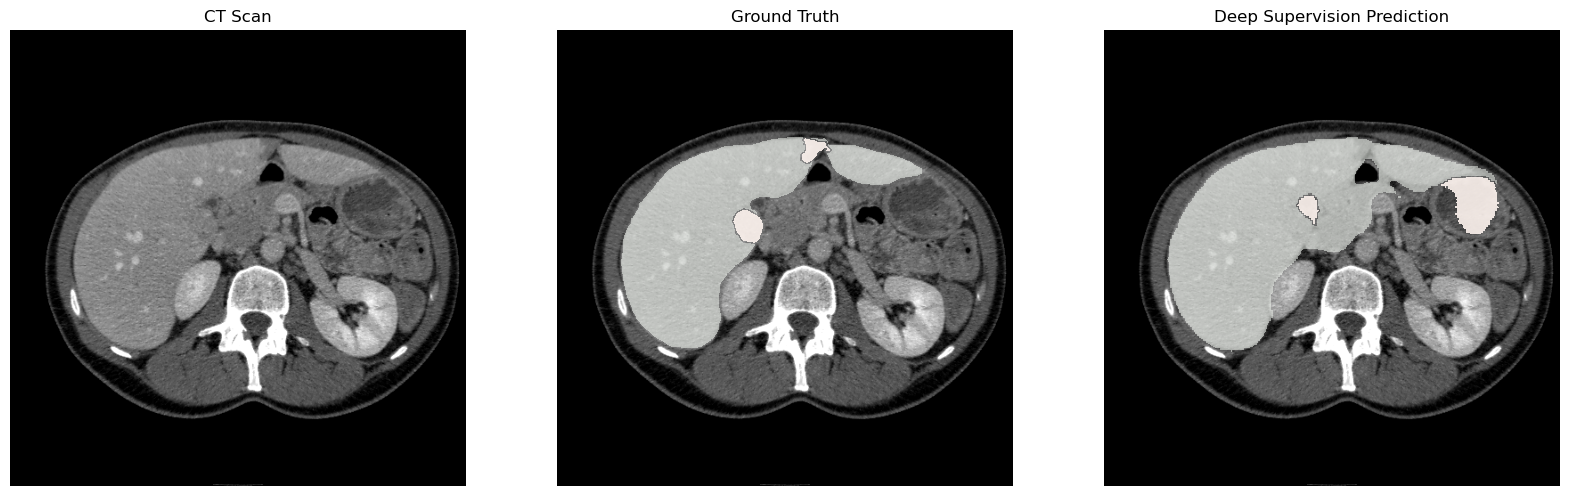

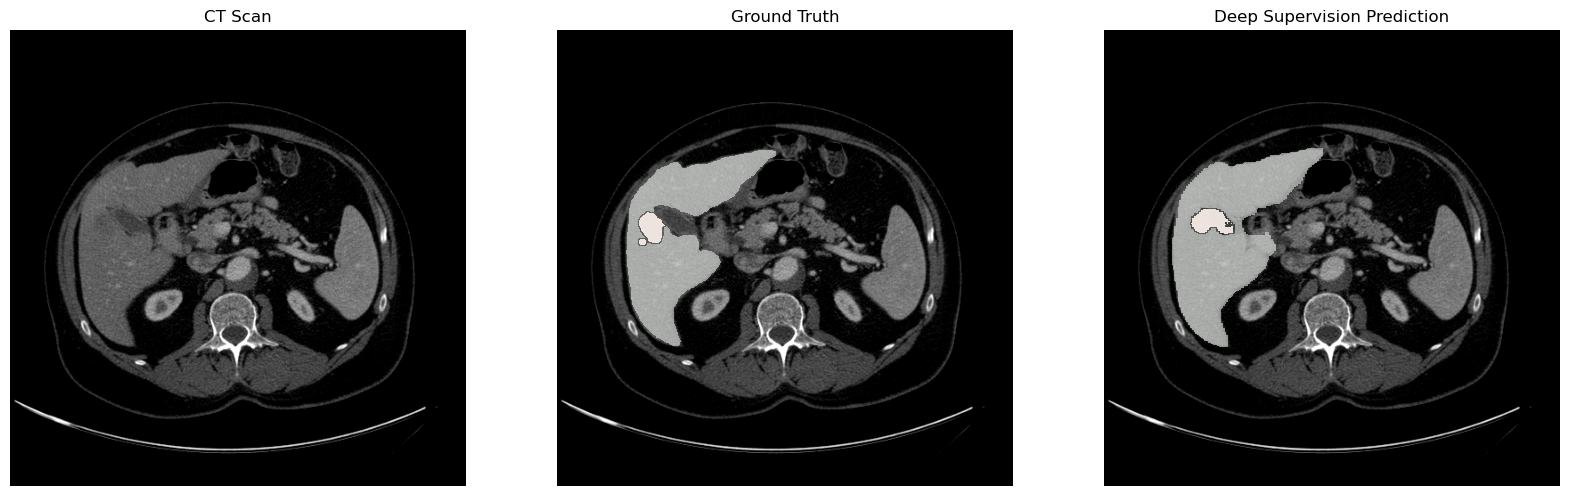

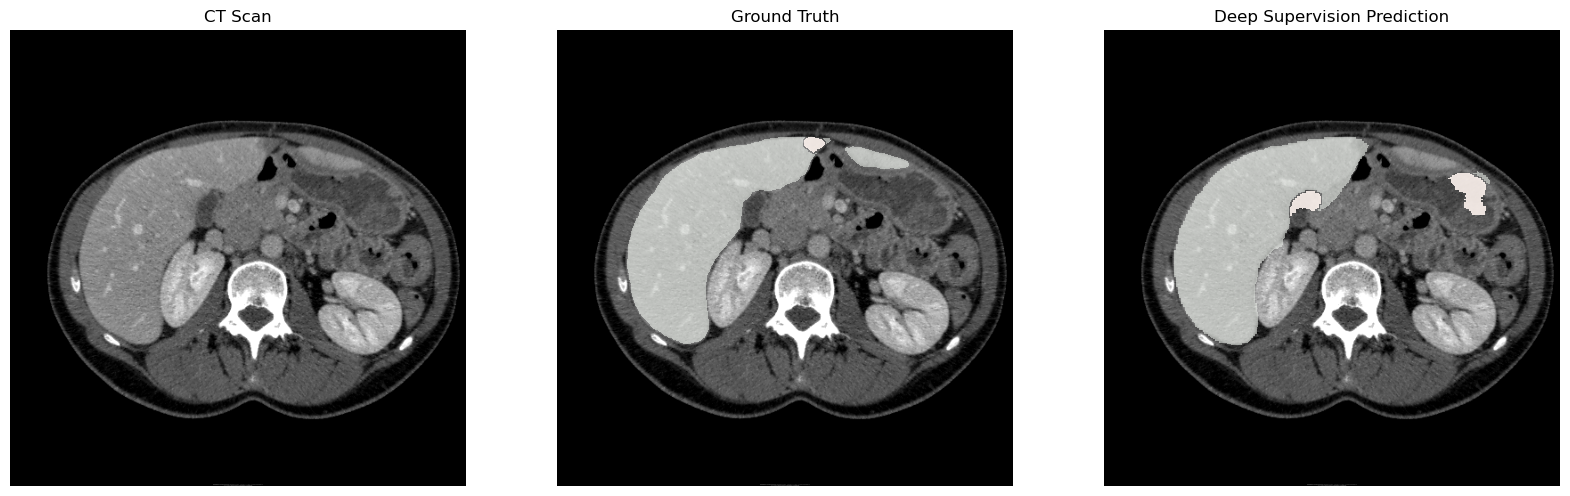

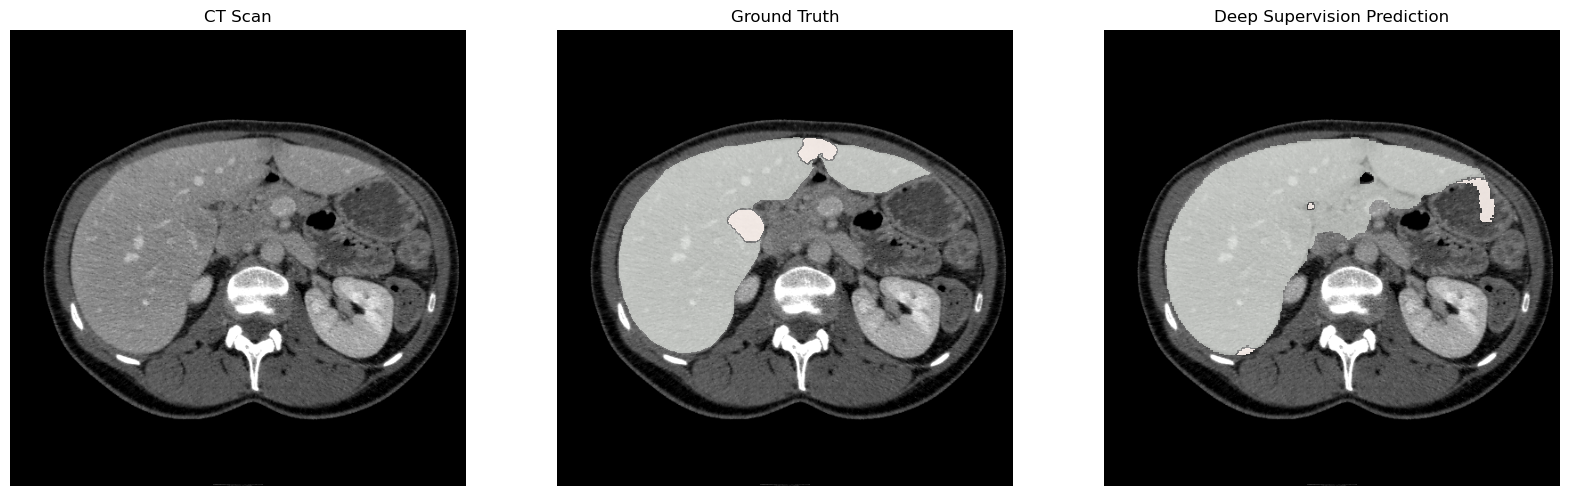

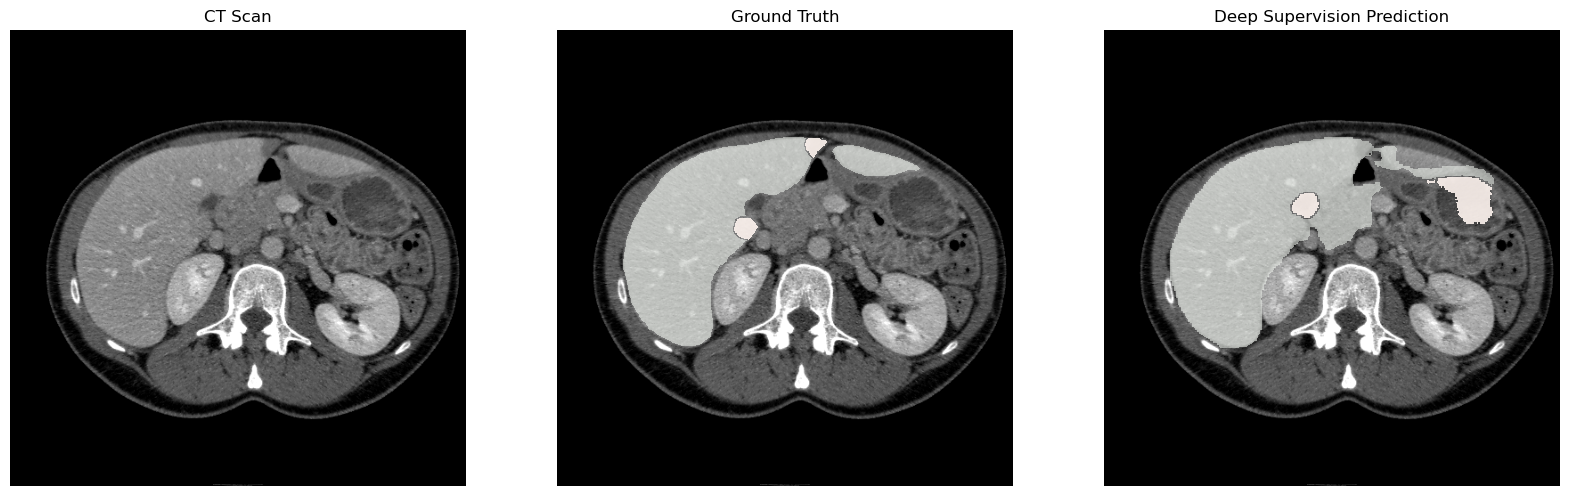

In [24]:
#نتائج التجربة الرابعة
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

model = DenseUNet_DS(n_classes=3).to(DEVICE)

chk_path = "C://Users//Motasem//Desktop//FINAL RESULT CV//best_model_deep_supervision (1).pth"

if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=DEVICE))
    print("Model loaded successfully")
else:
    print(f"File '{chk_path}' not found")

model.eval()

def visualize_sample(dataset, idx):
    image, mask = dataset[idx]

    with torch.no_grad():
        input_tensor = torch.tensor(image).unsqueeze(0).to(DEVICE)
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).cpu().squeeze(0).numpy()

    image = image.squeeze(0).numpy()
    mask = mask.numpy()

    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    ax[0].imshow(image, cmap="gray")
    ax[0].set_title("CT Scan")
    ax[0].axis("off")

    ax[1].imshow(image, cmap="gray")
    ax[1].imshow(np.ma.masked_where(mask != 1, mask), cmap="Greens", alpha=0.5)
    ax[1].imshow(np.ma.masked_where(mask != 2, mask), cmap="Reds", alpha=0.9)
    ax[1].set_title("Ground Truth")
    ax[1].axis("off")

    ax[2].imshow(image, cmap="gray")
    ax[2].imshow(np.ma.masked_where(pred_mask != 1, pred_mask), cmap="Greens", alpha=0.5)
    ax[2].imshow(np.ma.masked_where(pred_mask != 2, pred_mask), cmap="Reds", alpha=0.9)
    ax[2].set_title("Deep Supervision Prediction")
    ax[2].axis("off")

    plt.show()


print("Searching for tumor slices in test set")

test_dataset_ref = test_loader.dataset
tumor_indices = []

for i in range(len(test_dataset_ref)):
    _, m = test_dataset_ref[i]
    if 2 in m:
        tumor_indices.append(i)

if len(tumor_indices) > 0:
    print(f"Found {len(tumor_indices)} slices with tumors")
    selected = random.sample(tumor_indices, min(5, len(tumor_indices)))
    for idx in selected:
        visualize_sample(test_dataset_ref, idx)
else:
    print("No tumor slices found")


In [26]:
import numpy as np
import torch
from tqdm import tqdm
import os

def calculate_dice_metric(pred, target):
    smooth = 1e-5
    pred_flat = pred.flatten()
    target_flat = target.flatten()
    intersection = (pred_flat * target_flat).sum()
    return (2.0 * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)


print("Calculating metrics for Deep Supervision model")

model = DenseUNet_DS(n_classes=3).to(DEVICE)
chk_path = "C://Users//Motasem//Desktop//FINAL RESULT CV//best_model_deep_supervision (1).pth"


if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=DEVICE))
else:
    print("Weights not found")

model.eval()

liver_scores = []
tumor_scores = []

loader_to_test = test_loader

with torch.no_grad():
    for image, mask in tqdm(loader_to_test):
        image = image.to(DEVICE)
        mask = mask.cpu().numpy()

        output = model(image)
        pred_mask = torch.argmax(output, dim=1).cpu().numpy()

        for j in range(image.shape[0]):
            curr_pred = pred_mask[j]
            curr_true = mask[j]

            if np.sum(curr_true == 1) > 0:
                p_liver = (curr_pred == 1).astype(float)
                t_liver = (curr_true == 1).astype(float)
                liver_scores.append(calculate_dice_metric(p_liver, t_liver))

            if np.sum(curr_true == 2) > 0:
                p_tumor = (curr_pred == 2).astype(float)
                t_tumor = (curr_true == 2).astype(float)
                tumor_scores.append(calculate_dice_metric(p_tumor, t_tumor))


print("=" * 40)
print("FINAL DEEP SUPERVISION RESULTS (TEST SET)")
print("=" * 40)
print(f"Liver Dice Score: {np.mean(liver_scores) * 100:.2f}%")

if len(tumor_scores) > 0:
    print(f"Tumor Dice Score: {np.mean(tumor_scores) * 100:.2f}%")
else:
    print("Tumor Dice Score: N/A")

print("=" * 40)


Calculating metrics for Deep Supervision model


100%|██████████| 205/205 [01:35<00:00,  2.14it/s]

FINAL DEEP SUPERVISION RESULTS (TEST SET)
Liver Dice Score: 81.44%
Tumor Dice Score: 17.62%


In [15]:
!pip install scikit-image trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 27.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.6/736.6 kB 12.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-image] [scikit-image]


In [27]:
from skimage import measure
import trimesh
import cv2
import os
import numpy as np
import torch
from tqdm import tqdm

print("Preparing 3D reconstruction from Deep Supervision model")

model = DenseUNet_DS(n_classes=3).to(DEVICE)
chk_path = "best_model_deep_supervision.pth"

if os.path.exists(chk_path):
    model.load_state_dict(torch.load(chk_path, map_location=DEVICE))
    print("Model loaded successfully")
else:
    print(f"File '{chk_path}' not found")

model.eval()

target_patient_id = None
max_tumor_slices = 0

for pid in test_pids:
    patient_masks = patient_map[pid]["masks"]
    tumor_count = 0
    for m_path in patient_masks:
        mask = np.load(m_path)
        if np.sum(mask == 2) > 0:
            tumor_count += 1

    if tumor_count > max_tumor_slices:
        max_tumor_slices = tumor_count
        target_patient_id = pid

if target_patient_id is None:
    print("No tumor patient found in test set, selecting first patient")
    target_patient_id = test_pids[0]

print(f"Selected patient: {target_patient_id} | Tumor slices: {max_tumor_slices}")

volume_preds = []
patient_img_paths = sorted(patient_map[target_patient_id]["images"])

print("Predicting slices and building volume")

with torch.no_grad():
    for img_path in tqdm(patient_img_paths):
        image = np.load(img_path).astype(np.float32)
        image = cv2.resize(image, (512, 512))
        input_tensor = torch.from_numpy(image).unsqueeze(0).unsqueeze(0).to(DEVICE)
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).cpu().squeeze(0).numpy()
        volume_preds.append(pred_mask)

volume_3d = np.array(volume_preds)
print(f"Volume shape: {volume_3d.shape}")

def save_mesh(volume, label_id, filename, color):
    print(f"Processing: {filename}")

    if np.sum(volume == label_id) == 0:
        print(f"Label {label_id} not found in volume for {filename}")
        return

    try:
        verts, faces, normals, values = measure.marching_cubes(volume == label_id, level=0.5)
        mesh = trimesh.Trimesh(vertices=verts, faces=faces)
        trimesh.smoothing.filter_laplacian(mesh, iterations=8)
        mesh.visual.face_colors = color
        mesh.export(filename)
        print(f"Saved: {filename}")
    except Exception as e:
        print(f"Error while building {filename}: {e}")

save_mesh(volume_3d, 1, "liver_3d.obj", [0, 255, 0, 100])
save_mesh(volume_3d, 2, "tumor_3d.obj", [255, 0, 0, 255])

print("3D reconstruction completed")
print("Files: liver_3d.obj, tumor_3d.obj")


Preparing 3D reconstruction from Deep Supervision model
File 'best_model_deep_supervision.pth' not found
Selected patient: 3Dircadb1.9 | Tumor slices: 30
Predicting slices and building volume


100%|██████████| 89/89 [00:44<00:00,  1.99it/s]


Volume shape: (89, 512, 512)
Processing: liver_3d.obj
Error while building liver_3d.obj: Surface level must be within volume data range.
Processing: tumor_3d.obj
Label 2 not found in volume for tumor_3d.obj
3D reconstruction completed
Files: liver_3d.obj, tumor_3d.obj


In [ ]:
#  (Architecture Definitions)
import torch
import torch.nn as nn
from torchvision import models

class DenseUNet169(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.base_model = models.densenet169(weights=None)
        self.base_model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.enc0 = nn.Sequential(self.base_model.features.conv0, self.base_model.features.norm0, self.base_model.features.relu0)
        self.pool0 = self.base_model.features.pool0
        self.denseblock1 = self.base_model.features.denseblock1
        self.transition1 = self.base_model.features.transition1
        self.denseblock2 = self.base_model.features.denseblock2
        self.transition2 = self.base_model.features.transition2
        self.denseblock3 = self.base_model.features.denseblock3
        self.transition3 = self.base_model.features.transition3
        self.denseblock4 = self.base_model.features.denseblock4

        self.up1 = nn.ConvTranspose2d(1664, 832, kernel_size=2, stride=2)
        self.conv1 = nn.Sequential(nn.Conv2d(832 + 1280, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True))
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = nn.Sequential(nn.Conv2d(256 + 512, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = nn.Sequential(nn.Conv2d(128 + 256, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = nn.Sequential(nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        x0 = self.enc0(x); x1 = self.pool0(x0); x1 = self.denseblock1(x1)
        x2 = self.transition1(x1); x2 = self.denseblock2(x2)
        x3 = self.transition2(x2); x3 = self.denseblock3(x3)
        x4 = self.transition3(x3); x4 = self.denseblock4(x4)
        d1 = self.up1(x4)
        if d1.shape != x3.shape: d1 = torch.nn.functional.interpolate(d1, size=x3.shape[2:])
        d1 = torch.cat((d1, x3), dim=1); d1 = self.conv1(d1)
        d2 = self.up2(d1)
        if d2.shape != x2.shape: d2 = torch.nn.functional.interpolate(d2, size=x2.shape[2:])
        d2 = torch.cat((d2, x2), dim=1); d2 = self.conv2(d2)
        d3 = self.up3(d2)
        if d3.shape != x1.shape: d3 = torch.nn.functional.interpolate(d3, size=x1.shape[2:])
        d3 = torch.cat((d3, x1), dim=1); d3 = self.conv3(d3)
        d4 = self.up4(d3)
        if d4.shape != x0.shape: d4 = torch.nn.functional.interpolate(d4, size=x0.shape[2:])
        d4 = torch.cat((d4, x0), dim=1); d4 = self.conv4(d4)
        out = self.final_up(d4)
        return self.final_conv(out)

class DenseUNet_DS(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.base_model = models.densenet169(weights=None)
        self.base_model.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.enc0 = nn.Sequential(self.base_model.features.conv0, self.base_model.features.norm0, self.base_model.features.relu0)
        self.pool0 = self.base_model.features.pool0
        self.denseblock1 = self.base_model.features.denseblock1
        self.transition1 = self.base_model.features.transition1
        self.denseblock2 = self.base_model.features.denseblock2
        self.transition2 = self.base_model.features.transition2
        self.denseblock3 = self.base_model.features.denseblock3
        self.transition3 = self.base_model.features.transition3
        self.denseblock4 = self.base_model.features.denseblock4
        self.up1 = nn.ConvTranspose2d(1664, 832, kernel_size=2, stride=2)
        self.conv1 = nn.Sequential(nn.Conv2d(832 + 1280, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True))
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = nn.Sequential(nn.Conv2d(256 + 512, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = nn.Sequential(nn.Conv2d(128 + 256, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = nn.Sequential(nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.ds_out1 = nn.Conv2d(256, n_classes, kernel_size=1)
        self.ds_out2 = nn.Conv2d(128, n_classes, kernel_size=1)
        self.final_out = nn.Sequential(nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.Conv2d(32, n_classes, kernel_size=1))

    def forward(self, x):
        x0 = self.enc0(x); x1 = self.pool0(x0); x1 = self.denseblock1(x1)
        x2 = self.transition1(x1); x2 = self.denseblock2(x2)
        x3 = self.transition2(x2); x3 = self.denseblock3(x3)
        x4 = self.transition3(x3); x4 = self.denseblock4(x4)
        d1 = self.up1(x4)
        if d1.shape != x3.shape: d1 = torch.nn.functional.interpolate(d1, size=x3.shape[2:])
        d1 = torch.cat((d1, x3), dim=1); d1 = self.conv1(d1)
        d2 = self.up2(d1)
        if d2.shape != x2.shape: d2 = torch.nn.functional.interpolate(d2, size=x2.shape[2:])
        d2 = torch.cat((d2, x2), dim=1); d2 = self.conv2(d2)
        out1 = self.ds_out1(d2)
        d3 = self.up3(d2)
        if d3.shape != x1.shape: d3 = torch.nn.functional.interpolate(d3, size=x1.shape[2:])
        d3 = torch.cat((d3, x1), dim=1); d3 = self.conv3(d3)
        out2 = self.ds_out2(d3)
        d4 = self.up4(d3)
        if d4.shape != x0.shape: d4 = torch.nn.functional.interpolate(d4, size=x0.shape[2:])
        d4 = torch.cat((d4, x0), dim=1); d4 = self.conv4(d4)
        final = self.final_out(d4)
        return final

In [ ]:
import os
import numpy as np
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader

experiments = [
    {
        "name": "Exp 1: Baseline",
        "file": "model_exp1_baseline.pth",
        "model_class": DenseUNet169
    },
    {
        "name": "Exp 2: High Weights",
        "file": "model_exp2_high_weights.pth",
        "model_class": DenseUNet169
    },
    {
        "name": "Exp 3: Low LR",
        "file": "model_exp3_low_lr.pth",
        "model_class": DenseUNet169
    },
    {
        "name": "Exp 4: Deep Supervision",
        "file": "best_model_deep_supervision (1).pth",     
        "model_class": DenseUNet_DS
    }
]

def get_dice_scores(model, loader, desc="Evaluating"):
    liver_scores = []
    tumor_scores = []
    
    with torch.no_grad():
        for images, masks in tqdm(loader, desc=desc, leave=False):
            images = images.to(DEVICE)
            masks = masks.cpu().numpy()
            
            output = model(images)
            
    
            if isinstance(output, tuple):
                output = output[0]
                
            pred_masks = torch.argmax(output, dim=1).cpu().numpy()
            
            for i in range(images.shape[0]):
                p = pred_masks[i]
                t = masks[i]
                
                # Liver Dice
                if np.sum(t == 1) > 0:
                    inter = ((p==1) & (t==1)).sum()
                    union = (p==1).sum() + (t==1).sum()
                    liver_scores.append((2.0*inter + 1e-5)/(union + 1e-5))
                    
                # Tumor Dice
                if np.sum(t == 2) > 0:
                    inter = ((p==2) & (t==2)).sum()
                    union = (p==2).sum() + (t==2).sum()
                    tumor_scores.append((2.0*inter + 1e-5)/(union + 1e-5))
    
    liv_avg = np.mean(liver_scores)*100 if liver_scores else 0
    tum_avg = np.mean(tumor_scores)*100 if tumor_scores else 0
    return liv_avg, tum_avg

print("⚙️ Recreating Loaders for Windows (num_workers=0)...")
if 'val_transform' in locals():
    val_loader = DataLoader(LiverDataset(val_imgs, val_masks, transform=val_transform), 
                            batch_size=16, shuffle=False, num_workers=0)

    test_loader = DataLoader(LiverDataset(test_imgs, test_masks, transform=val_transform), 
                             batch_size=16, shuffle=False, num_workers=0)
else:
    print("⚠️ Error: val_transform is not defined. Please run Cell 3 first.")

# 4. التنفيذ والطباعة
print("\n" + "="*105)
print(f"{'Experiment Name':<25} | {'Val Liver':<10} | {'Test Liver':<10} || {'Val Tumor':<10} | {'Test Tumor':<10}")
print("="*105)

for exp in experiments:
    file_path = exp["file"]
    
    if not os.path.exists(file_path):
        print(f"{exp['name']:<25} | {'FILE NOT FOUND (Skipped)':<50}")
        continue

    # تحميل الموديل
    try:
        model = exp["model_class"](n_classes=3).to(DEVICE)
        # weights_only=False لتجنب التحذير
        model.load_state_dict(torch.load(file_path, weights_only=False))
        model.eval()
        
        val_liv, val_tum = get_dice_scores(model, val_loader, desc="Val Loop")
        test_liv, test_tum = get_dice_scores(model, test_loader, desc="Test Loop")
        
        print(f"{exp['name']:<25} | {val_liv:.2f}%{'':<4} | {test_liv:.2f}%{'':<5} || {val_tum:.2f}%{'':<4} | {test_tum:.2f}%")
    except Exception as e:
        print(f"{exp['name']:<25} | Error: {e}")

print("="*105)

⚙️ Recreating Loaders for Windows (num_workers=0)...

Experiment Name           | Val Liver  | Test Liver || Val Tumor  | Test Tumor


Exp 1: Baseline           | 76.63%     | 83.93%      || 73.53%     | 17.70%


Exp 2: High Weights       | 75.09%     | 77.38%      || 64.56%     | 20.31%


Exp 3: Low LR             | 74.43%     | 81.31%      || 54.17%     | 13.09%


Exp 4: Deep Supervision   | 82.31%     | 81.44%      || 71.70%     | 17.61%
